# **Trabajo Final - Diplomatura en Ciencia de Datos**

## Global Tech Startups 2026

#### **Participantes**

- [Agüero Luciana](https://www.linkedin.com/in/luciana-ag%C3%BCero-0a19082a8/)
- [Gutierrez Sídoli Priscila](https://www.linkedin.com/in/priscilagsidoliiq/)
- [Maldonado Vanesa](https://www.linkedin.com/in/maldonadovanesa/)
- [Paredes Silvina](https://www.linkedin.com/in/silvina-cecilia-paredes-703aa33a/)

**Pregunta principal:** ¿Qué factores financieros, tecnológicos y geográficos están asociados con la valuación de una startup y qué tan bien podemos predecirla mediante Machine Learning para asesorar inversionistas utilizando el modelo como herramienta de apoyo?

- [Valuación de Startups con Machine Learning — GitHub](https://github.com/PriscilagsData/ValuacionStartups_MachineLearning)

___

**Público receptor:** Inversionistas interesados en Startups tecnológicas

(es herramienta de apoyo porque claramente no reemplazaría una valuación financiera completa)

___

**Objetivo**

Explicar qué hace valiosa a una startup tecnológica y qué tan bien podemos predecir su valuación mediante datos observables.

**Mapa general del proyecto**

- Comprender y validar los datos.
- Explorar cómo cambia la valuación según características financieras, geográficas y tecnológicas.
- Comprobar estadísticamente algunas relaciones.
- Preparar las variables para Machine Learning.
- Comparar modelos de regresión.
- Validar el mejor modelo.
- Interpretar resultados, errores y variables importantes.
- Como análisis adicional, segmentar las startups mediante clustering.


*Aclaración: El dataset es sintético y se utilizó con fines académicos. Por lo tanto, permite evaluar la metodología, pero los resultados no deben generalizarse directamente al mercado real.
"...advanced real-world synthetic dataset tracking the evolution of the global technology ecosystem..." (https://www.kaggle.com/datasets/saitejabandaruin/global-tech-startups-pipeline)*



In [ ]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn joblib

# pandas, numpy	Manipulación y cálculo de datos ; matplotlib, seaborn	Gráficos ; scipy.stats	Pruebas estadísticas ;
# scikit-learn	Preparación, entrenamiento y evaluación de modelos

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap, Normalize
import seaborn as sns
from IPython.display import display

from scipy.stats import spearmanr, kruskal
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Fijamos aleatoriedad para comparar modelos utilizando la misma division de datos (puede ser cualquier otro num)
random_state = 42
# Aplica un estilo de gráficos con fondo blanco y cuadrícula, que facilita leer valores
sns.set_theme(style="whitegrid")
# Permite mostrar todas las columnas del DataFrame, sin ocultarlas por superar un límite
pd.set_option("display.max_columns", None)
# Define un ancho de referencia de 180 caracteres para la representación textual de las tablas
pd.set_option("display.width", 180)
# Hace que los gráficos de Matplotlib aparezcan dentro del notebook. Instrucción especial de IPython/Jupyter, no de Python estándar
%matplotlib inline


## 1. Carga del dataset

Aclaraciones:

La unidad de análisis es una startup por fila.

La variable que queremos predecir es: **Valuation_USD_Millions** (valuación de la empresa en millones de dólares)
___
**Tipos de variables**
- **Identificador:** Company_ID (Cualitativa nominal)
- **Categóricas:** dominio (nominal), país (nominal), ciudad (nominal), etapa (ordinal), tipo de inversor (nominal), adopción de IA (ordinal) y estado de adquisición (ordinal).
- **Numéricas:** financiamiento (continua), valuación (continua), ingresos (continua), burn rate (continua), runway (continua) y cantidad de empleados (discreta).
- **Temporal:** año de fundación (discreta).

## 2. Control de calidad

In [ ]:
# Ruta del archivo
csv_path = Path("/content/global_tech_startups_2026.csv")

# Lectura del dataset
df = pd.read_csv(csv_path)

print(f"Filas df: {df.shape[0]:,} | Columnas df: {df.shape[1]}")
print()
print("Info dataset")
display(df.head())
print(" ")
df.info()

# Variables categóricas
columnas_categoricas = ["Domain", "Country", "City", "Funding_Stage", "Investor_Tier", "AI_Adoption_Level", "Acquisition_Status"]

# Cantidad de categorías diferentes por variable
resumen = (
    df[columnas_categoricas].nunique().rename_axis("Variable").reset_index(name="Cantidad de categorías"))

display(resumen)

Filas df: 25,000 | Columnas df: 17

Info dataset


,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,21AB7B52,Generative AI,2018,India,Delhi NCR,Series B,71.56,537.21,23.86,4.41,15.9,330,0,330,Tier 3 (Angel/Seed),High,Closed
1,286A78B9,SpaceTech,2021,USA,Austin,Series B,48.40,313.33,32.70,6.03,7.9,310,0,310,"Tier 1 (e.g. Sequoia, a16z)",High,Independent
2,6437E24A,HealthTech,2013,China,Hangzhou,Pre-IPO,177.08,1886.47,103.93,12.94,13.6,654,168,486,Tier 3 (Angel/Seed),High,Closed
3,7463FAA4,SpaceTech,2019,China,Shenzhen,Seed,2.40,29.82,1.19,0.24,7.1,12,0,12,Tier 3 (Angel/Seed),High,Independent
4,0354E5FD,Generative AI,2021,USA,San Francisco,Series B,68.73,347.10,27.46,1.40,45.8,107,0,107,Tier 3 (Angel/Seed),NaN,Independent


 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company_ID                  25000 non-null  object 
 1   Domain                      25000 non-null  object 
 2   Founding_Year               25000 non-null  int64  
 3   Country                     25000 non-null  object 
 4   City                        25000 non-null  object 
 5   Funding_Stage               25000 non-null  object 
 6   Total_Funding_USD_Millions  25000 non-null  float64
 7   Valuation_USD_Millions      25000 non-null  float64
 8   Revenue_ARR_Millions        25000 non-null  float64
 9   Monthly_Burn_Rate_Millions  25000 non-null  float64
 10  Runway_Months_2024          25000 non-null  float64
 11  Peak_Headcount_2023         25000 non-null  int64  
 12  Layoffs_2024_2025           25000 non-null  int64  
 13  Current_Headcount_2026      2

,Variable,Cantidad de categorías
0,Domain,10
1,Country,10
2,City,29
3,Funding_Stage,6
4,Investor_Tier,5
5,AI_Adoption_Level,3
6,Acquisition_Status,5


In [ ]:
# Reemplazo los nulos por la palabra "None" ya que al leer el csv, el código interpreta los "None" como nulls (No adoptaron IA).
# El dataset original no contiene faltantes

df["AI_Adoption_Level"] = df["AI_Adoption_Level"].fillna("None")

In [ ]:
print("Valores nulos del dataset:", int(df.isna().sum().sum()))
print("Filas duplicadas del dataset:", df.duplicated().sum())

Valores nulos del dataset: 0
Filas duplicadas del dataset: 0


In [ ]:
print("Resumen descriptivo")
display(df.describe(include="all").T)

Resumen descriptivo


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company_ID,25000,25000,3B52CFDB,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Domain,25000,10,Generative AI,5051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Founding_Year,25000.0,NaN,NaN,NaN,2018.95156,2.805325,2012.0,2018.0,2019.0,2021.0,2025.0
Country,25000,10,USA,11186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,25000,29,Miami,1919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Funding_Stage,25000,6,Seed,8686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Funding_USD_Millions,25000.0,NaN,NaN,NaN,63.122252,261.342749,0.0,2.05,8.61,36.805,19713.1
Valuation_USD_Millions,25000.0,NaN,NaN,NaN,491.1144,2128.588997,1.0,29.02,72.73,277.9925,154794.01
Revenue_ARR_Millions,25000.0,NaN,NaN,NaN,35.388104,152.170392,0.04,1.77,4.86,18.2625,6180.03
Monthly_Burn_Rate_Millions,25000.0,NaN,NaN,NaN,3.292442,12.222378,0.05,0.43,0.72,2.26,738.15


## 3. Conteos de variables categóricas

In [ ]:
for col in ["Domain", "Country", "City", "Funding_Stage", "Investor_Tier", "AI_Adoption_Level", "Acquisition_Status"]:
    print(f"\n--- {col} ---")
    display(df[col].value_counts().to_frame("Cantidad"))


--- Domain ---


,Cantidad
Domain,
Generative AI,5051
HealthTech,3744
FinTech,3020
ClimateTech,2529
Robotics,2529
Cybersecurity,2451
Web3/Crypto,1958
Autonomous Vehicles,1271
EdTech,1246



--- Country ---


,Cantidad
Country,
USA,11186
China,3793
India,2478
UK,1931
Germany,1270
Israel,1270
Canada,1026
France,790
Singapore,751



--- City ---


...

,Cantidad
Investor_Tier,
Tier 3 (Angel/Seed),9916
Tier 2 (Mid-size VC),7502
Corporate VC (e.g. Google Ventures),3830
"Tier 1 (e.g. Sequoia, a16z)",2527
Bootstrapped,1225



--- AI_Adoption_Level ---


,Cantidad
AI_Adoption_Level,
High,9847
Medium,7546
Low,5078
None,2529



--- Acquisition_Status ---


,Cantidad
Acquisition_Status,
Independent,15373
Closed,5168
Acquired,2675
Acquired (Fire Sale),1148
IPO,636


#### **Descripción de columnas**

- **Company_ID**: Identificador alfanumérico único de la startup.
- **Domain**: Sector industrial (p. ej., IA generativa, Robótica, Tecnología espacial, Web3/Cripto).
- **Founding_Yea**r: Año de fundación oficial de la empresa (2012-2025).
- **Country**: País donde se encuentra la sede de la startup.
- **City**: Ciudad donde se encuentra la sede de la startup.
- **Funding_Stage**: Etapa actual de financiación de capital riesgo (p. ej., semilla, Serie A, pre-IPO).
- **Total_Funding_USD_Millions**: Financiación total de capital riesgo recaudada hasta la fecha (en millones de USD).
- **Valuation_USD_Millions**: Valoración estimada de la empresa (en millones de USD).
- **Revenue_ARR_Millions**: Ingresos recurrentes anuales (ARR) estimados (en millones de USD).
- **Monthly_Burn_Rate_Millions**: Gastos operativos calculados en función de la plantilla máxima.
- **Runway_Months_2024**: Número de meses que la empresa puede sobrevivir sin financiación (indicador crítico de posibles despidos).
- **Peak_Headcount_2023**: Número máximo de empleados alcanzado antes del "invierno tecnológico".
- **Layoffs_2024_2025**: Número de empleados despedidos durante la corrección del mercado tecnológico (modelado probabilísticamente).
- **Current_Headcount_2026**: Número de empleados tras los despidos.
- **Investor_Tier**: Categoría y calidad de los inversores principales de capital riesgo que respaldan a la empresa.
- **AI_Adoption_Level**: Métrica cualitativa que mide el grado de uso interno de la IA por parte de la empresa.
- **Acquisition_Status**: Estado actual de la empresa en el mercado (p. ej., independiente, adquirida, salida a bolsa/IPO, cerrada, venta de liquidación).

## 4. Feature Engineering

In [ ]:
# Antigüedad de la startup
df_model = df.copy()
df_model["Startup_Age"] = 2026 - df_model["Founding_Year"]

# Calculamos el gasto anual
df_model["Annual_Burn_Millions"] = (df_model["Monthly_Burn_Rate_Millions"] * 12)

# Ingresos anuales en relación con el gasto anual
df_model["Revenue_Burn_Ratio"] = (df_model["Revenue_ARR_Millions"]/ df_model["Annual_Burn_Millions"].replace(0, np.nan))

# Ingresos anuales en relación con el financiamiento recibido
df_model["Revenue_Funding_Ratio"] = (df_model["Revenue_ARR_Millions"]/ df_model["Total_Funding_USD_Millions"].replace(0, np.nan))

# No usamos Valuation/Funding como predictor porque contiene el target y produciría data leakage
display(df_model[["Startup_Age", "Revenue_Burn_Ratio", "Revenue_Funding_Ratio"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
Startup_Age,25000.0,7.048440,2.805325,1.000000,5.000000,7.000000,8.000000,14.000000
Revenue_Burn_Ratio,25000.0,0.771080,0.773039,0.005128,0.291667,0.534010,0.962133,9.530556
Revenue_Funding_Ratio,23775.0,0.859707,0.925027,0.103920,0.383157,0.596723,1.014472,35.000000


## 5. EDA - Variables categóricas

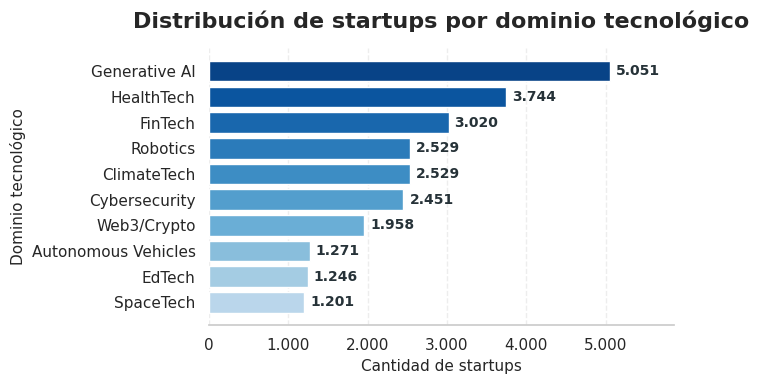

In [ ]:
# 5.1 Startups por dominio

# Cantidad de startups por dominio tecnológico
counts_domain = (df["Domain"].value_counts().sort_values(ascending=True))

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(7, 4))

# Gráfico de barras horizontales
bars = ax.barh(
    counts_domain.index,
    counts_domain.values,
    color=sns.color_palette(
        "Blues",
        n_colors=len(counts_domain) + 3
    )[3:]
)

# Cantidad al final de cada barra
for bar, valor in zip(bars, counts_domain.values):
    ax.text(
        valor + counts_domain.max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:,.0f}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#263238"
    )

# Título y etiquetas
ax.set_title(
    "Distribución de startups por dominio tecnológico",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Cantidad de startups",
    fontsize=11
)

ax.set_ylabel(
    "Dominio tecnológico",
    fontsize=11
)

# Separador de miles
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, posicion: f"{x:,.0f}".replace(",", "."))
)

# Espacio para las etiquetas
ax.set_xlim(0, counts_domain.max() * 1.16)

# Mejoramos diseño
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()



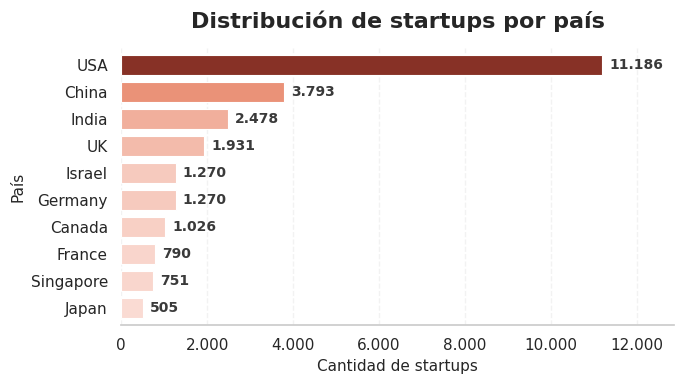

In [ ]:
# 5.2 Startups por país

# Cantidad de startups por país
counts_country = (
    df["Country"]
    .value_counts()
    .sort_values(ascending=True)
)

# Crear paleta degradada personalizada
cmap_terracota = LinearSegmentedColormap.from_list(
    "terracota",
    [
        "#FADBD3",  # Terracota claro
        "#E98B70",  # Terracota medio
        "#C6533C",  # Terracota intenso
        "#873126"   # Terracota oscuro
    ]
)

# Asignaamos un color según la cantidad
normalizador = Normalize(
    vmin=counts_country.min(),
    vmax=counts_country.max()
)

colores = cmap_terracota(normalizador(counts_country.values))

# Creamos gráfico
fig, ax = plt.subplots(figsize=(7, 4))

counts_country.plot(
    kind="barh",
    ax=ax,
    color=colores,
    edgecolor="white",
    linewidth=0.8,
    width=0.75
)

# Cantidades al final de las barras
for barra in ax.patches:
    valor = barra.get_width()

    ax.text(
        valor + counts_country.max() * 0.015,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:,.0f}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#3A3A3A"
    )

# Título y etiquetas
ax.set_title(
    "Distribución de startups por país",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Cantidad de startups",
    fontsize=11
)

ax.set_ylabel(
    "País",
    fontsize=11
)

# Formato de miles con punto
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, posicion: f"{x:,.0f}".replace(",", "."))
)

# Espacio para etiquetas
ax.set_xlim(0, counts_country.max() * 1.15)

# Diseño
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

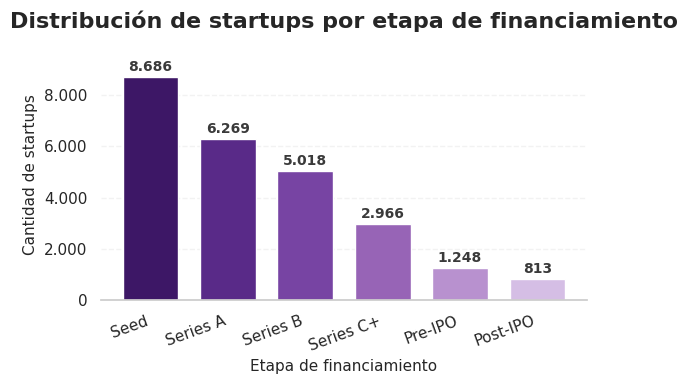

In [ ]:
# 5.3 Startups por etapa de financiamiento

# Orden lógico de las etapas
stage_order = ["Seed", "Series A", "Series B", "Series C+", "Pre-IPO", "Post-IPO"]

# Contar startups y respetar orden
stage_counts = (df["Funding_Stage"].value_counts().reindex(stage_order).fillna(0))

# Colores
cmap_violeta = LinearSegmentedColormap.from_list(
    "violeta",
    ["#EDE7F6",  # Muy claro
      "#C5A3D9","#9561B5","#663399",
      "#3D1766"   # Muy oscuro
    ]
)

colores = cmap_violeta(np.linspace(1, 0.15, len(stage_counts)))

# Gráfico
fig, ax = plt.subplots(figsize=(6, 4))

barras = ax.bar(
    stage_counts.index,
    stage_counts.values,
    color=colores,
    edgecolor="white",
    linewidth=1,
    width=0.72
)

# Cantidades sobre las barras
for barra, valor in zip(barras, stage_counts.values):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + stage_counts.max() * 0.015,
        f"{valor:,.0f}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#3A3A3A"
    )

# Título y etiquetas
ax.set_title(
    "Distribución de startups por etapa de financiamiento",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Etapa de financiamiento",
    fontsize=11
)

ax.set_ylabel(
    "Cantidad de startups",
    fontsize=11
)

# Formato de miles con punto
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, posicion: f"{x:,.0f}".replace(",", ".")
    )
)

# Espacio para las etiquetas
ax.set_ylim(0, stage_counts.max() * 1.13)

# Diseño
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

- Seed: Financiamiento inicial para crear el Producto Mínimo Viable (MVP) y validar el encaje de la idea en el mercado.
- Series A: Capital para optimizar el modelo de negocio y empezar a escalar tras demostrar las primeras métricas de tracción.
- Series B: Inversión enfocada en expandir la cuota de mercado y acelerar el crecimiento de operaciones ya probadas.
- Series C+: Financiamiento para empresas maduras que buscan la expansión internacional y la adquisición de otros competidores.
- Pre-IPO: Última ronda privada para preparar la estructura corporativa y financiera antes de cotizar en la bolsa.
- Post-IPO: Acceso al capital público en el mercado de valores para financiar el crecimiento masivo a largo plazo.

## 6. EDA - Distribuciones financieras

Distribuciones financieras


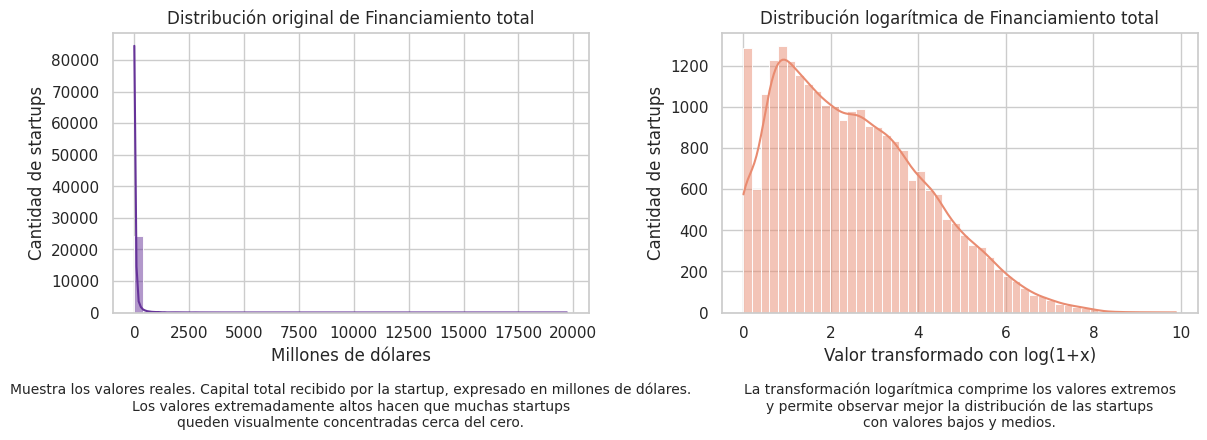

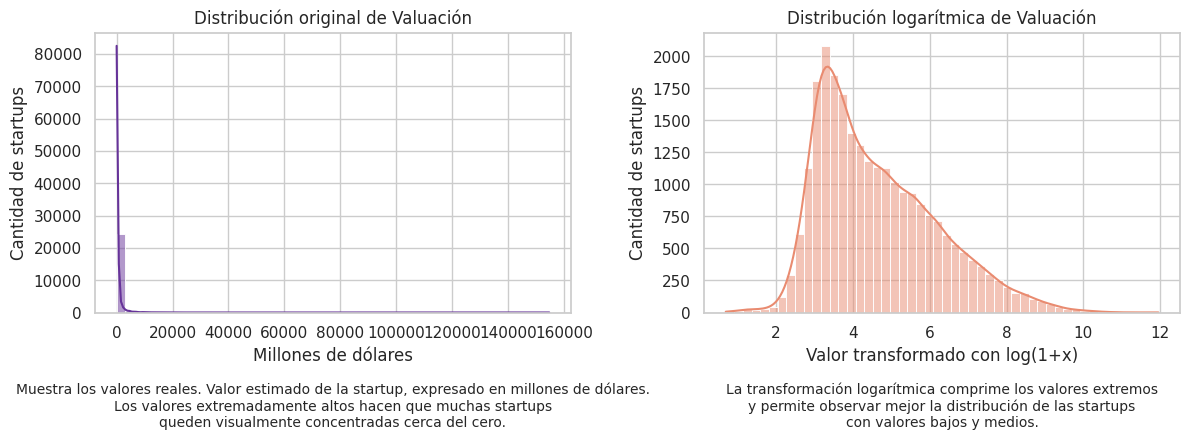

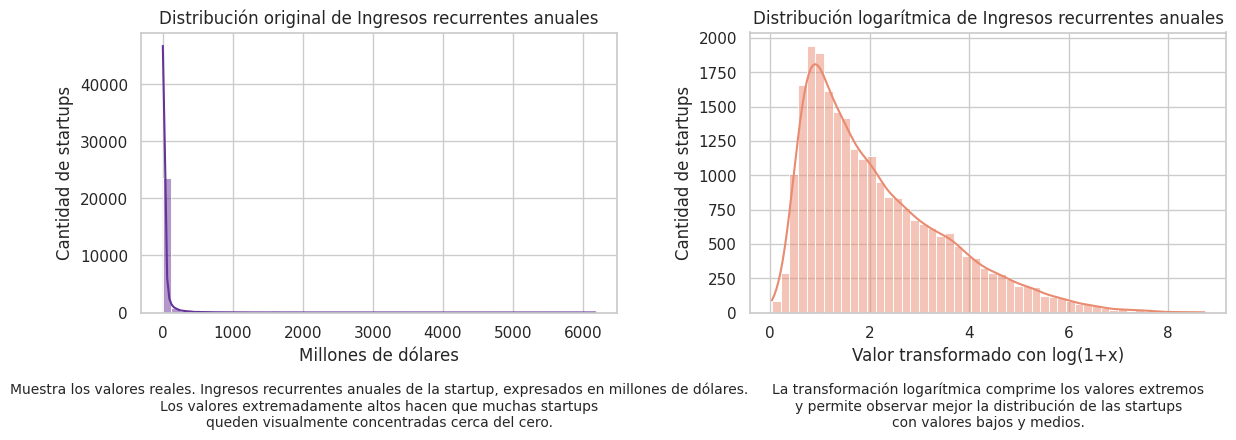

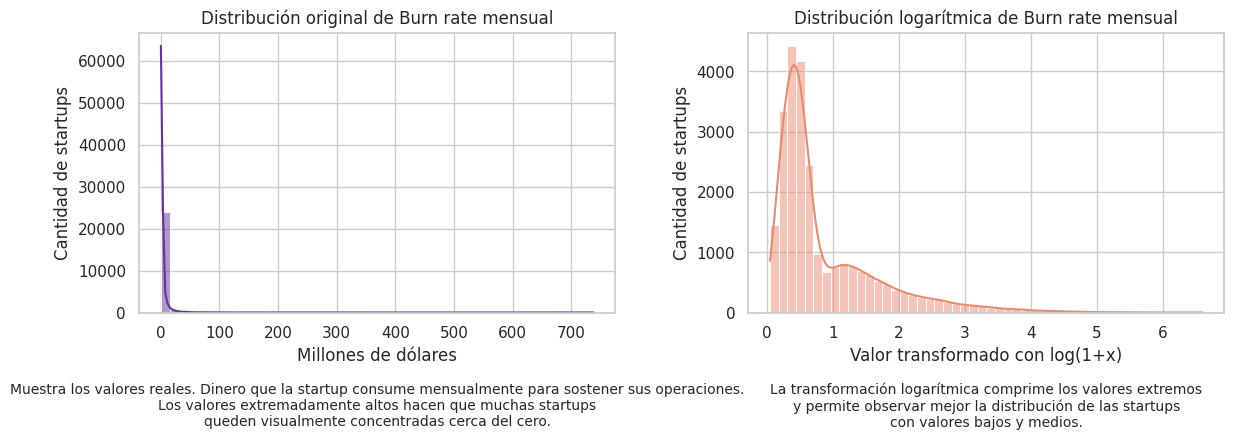

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Distribuciones financieras")

# Nombres y explicaciones en español
informacion_variables = {
    "Total_Funding_USD_Millions": {
        "nombre": "Financiamiento total",
        "explicacion": (
            "Capital total recibido por la startup, "
            "expresado en millones de dólares."
        )
    },
    "Valuation_USD_Millions": {
        "nombre": "Valuación",
        "explicacion": (
            "Valor estimado de la startup, "
            "expresado en millones de dólares."
        )
    },
    "Revenue_ARR_Millions": {
        "nombre": "Ingresos recurrentes anuales",
        "explicacion": (
            "Ingresos recurrentes anuales de la startup, "
            "expresados en millones de dólares."
        )
    },
    "Monthly_Burn_Rate_Millions": {
        "nombre": "Burn rate mensual",
        "explicacion": (
            "Dinero que la startup consume mensualmente "
            "para sostener sus operaciones."
        )
    }
}

# Genera 4 bloques de 2 gráficos cada uno
for columna, informacion in informacion_variables.items():

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    nombre = informacion["nombre"]
    explicacion = informacion["explicacion"]

    # Gráfico izquierdo: valores originales
    sns.histplot(
        df[columna],
        bins=50,
        kde=True,
        ax=axes[0],
        color="#663399"
    )

    axes[0].set_title(f"Distribución original de {nombre}")
    axes[0].set_xlabel("Millones de dólares")
    axes[0].set_ylabel("Cantidad de startups")

    axes[0].text(
        0.5,
        -0.25,
        f"Muestra los valores reales. {explicacion}\n"
        "Los valores extremadamente altos hacen que muchas startups\n"
        "queden visualmente concentradas cerca del cero.",
        transform=axes[0].transAxes,
        ha="center",
        va="top",
        fontsize=10
    )

    # Gráfico derecho: transformación logarítmica
    sns.histplot(
        np.log1p(df[columna]),
        bins=50,
        kde=True,
        ax=axes[1],
        color="#E98B70"
    )

    axes[1].set_title(f"Distribución logarítmica de {nombre}")
    axes[1].set_xlabel("Valor transformado con log(1+x)")
    axes[1].set_ylabel("Cantidad de startups")

    axes[1].text(
        0.5,
        -0.25,
        "La transformación logarítmica comprime los valores extremos\n"
        "y permite observar mejor la distribución de las startups\n"
        "con valores bajos y medios.",
        transform=axes[1].transAxes,
        ha="center",
        va="top",
        fontsize=10
    )

    # Deja espacio debajo para las explicaciones
    fig.subplots_adjust(
        bottom=0.32,
        wspace=0.28
    )

    plt.show()

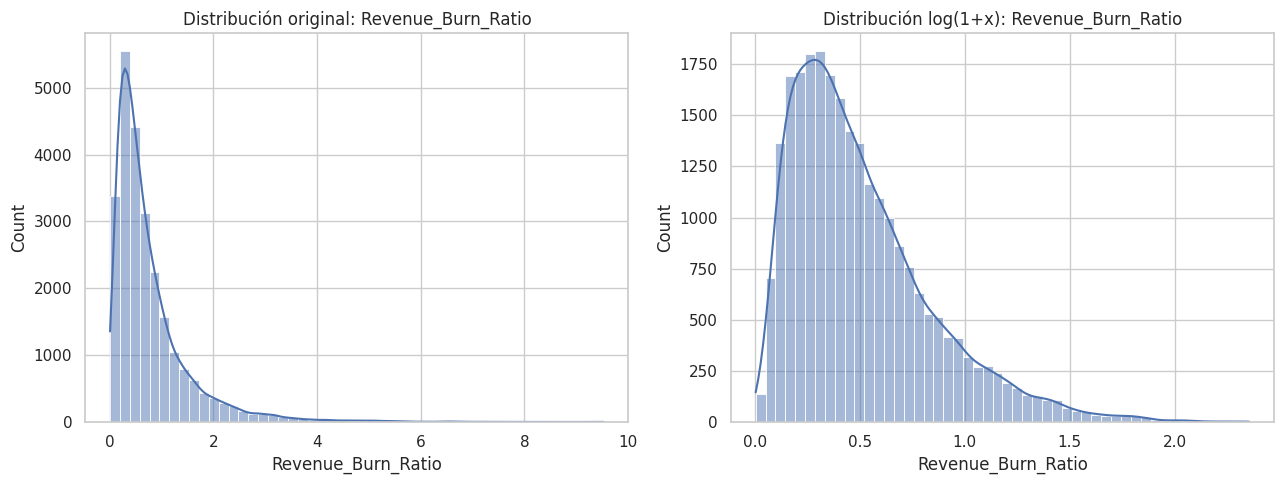

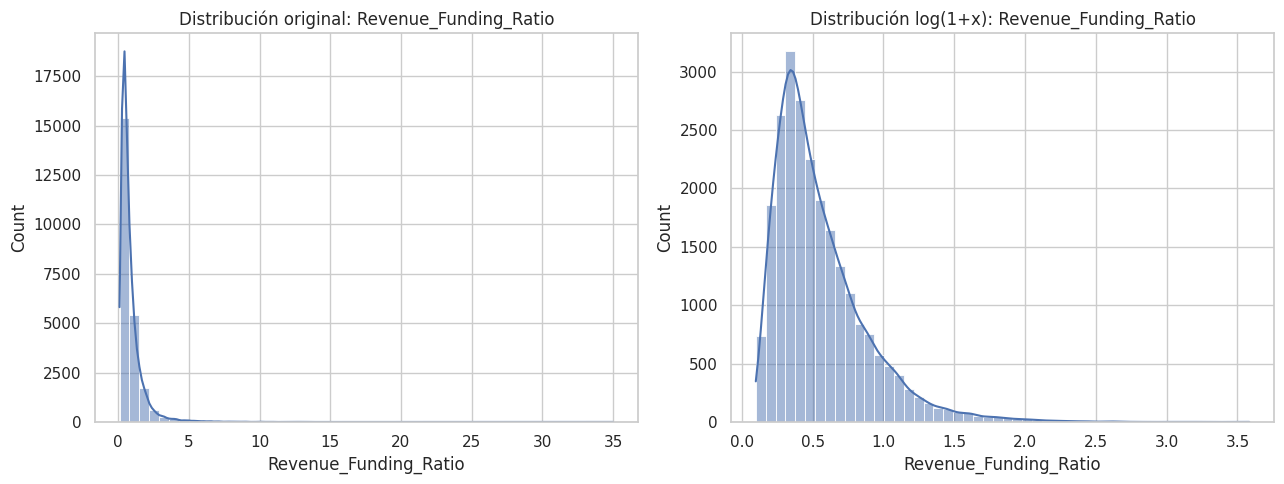

In [ ]:
new_financial_cols = [
    "Revenue_Burn_Ratio",
    "Revenue_Funding_Ratio"
]

# Revenue_Burn_Ratio: relación entre los ingresos (Revenue) y el Burn Rate, es decir, cuánto dinero está gastando o “quemando” la startup. Fórmula típica: Revenue / Burn_Rate
# Cuanto más alto sea el ratio, mejor: indica que la empresa genera más ingresos en relación con lo que gasta.

# Revenue_Funding_Ratio: relación entre los ingresos de la startup y el capital total recibido de inversores (Funding). Fórmula típica: Revenue / Funding


for col in new_financial_cols:
    fig, axes = plt.subplots(1, 2, figsize=(13,5))
    sns.histplot(df_model[col], bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribución original: {col}")
    sns.histplot(np.log1p(df_model[col]), bins=50, kde=True, ax=axes[1])
    axes[1].set_title(f"Distribución log(1+x): {col}")
    plt.tight_layout()
    plt.show()

    # Conclusion de gráficos: La variable original presenta una fuerte asimetría positiva: muchas startups tienen ratios bajos y pocas presentan ratios muy elevados.
    # La transformación log(1+x) reduce esa asimetría y genera una distribución más equilibrada, aunque no llega a ser perfectamente normal.
    # TENDENCIA NORMAL EN STARTUPS (FAMOSAS EMPRESAS "ESTRELLA")

## 7. Valuación por segmentos

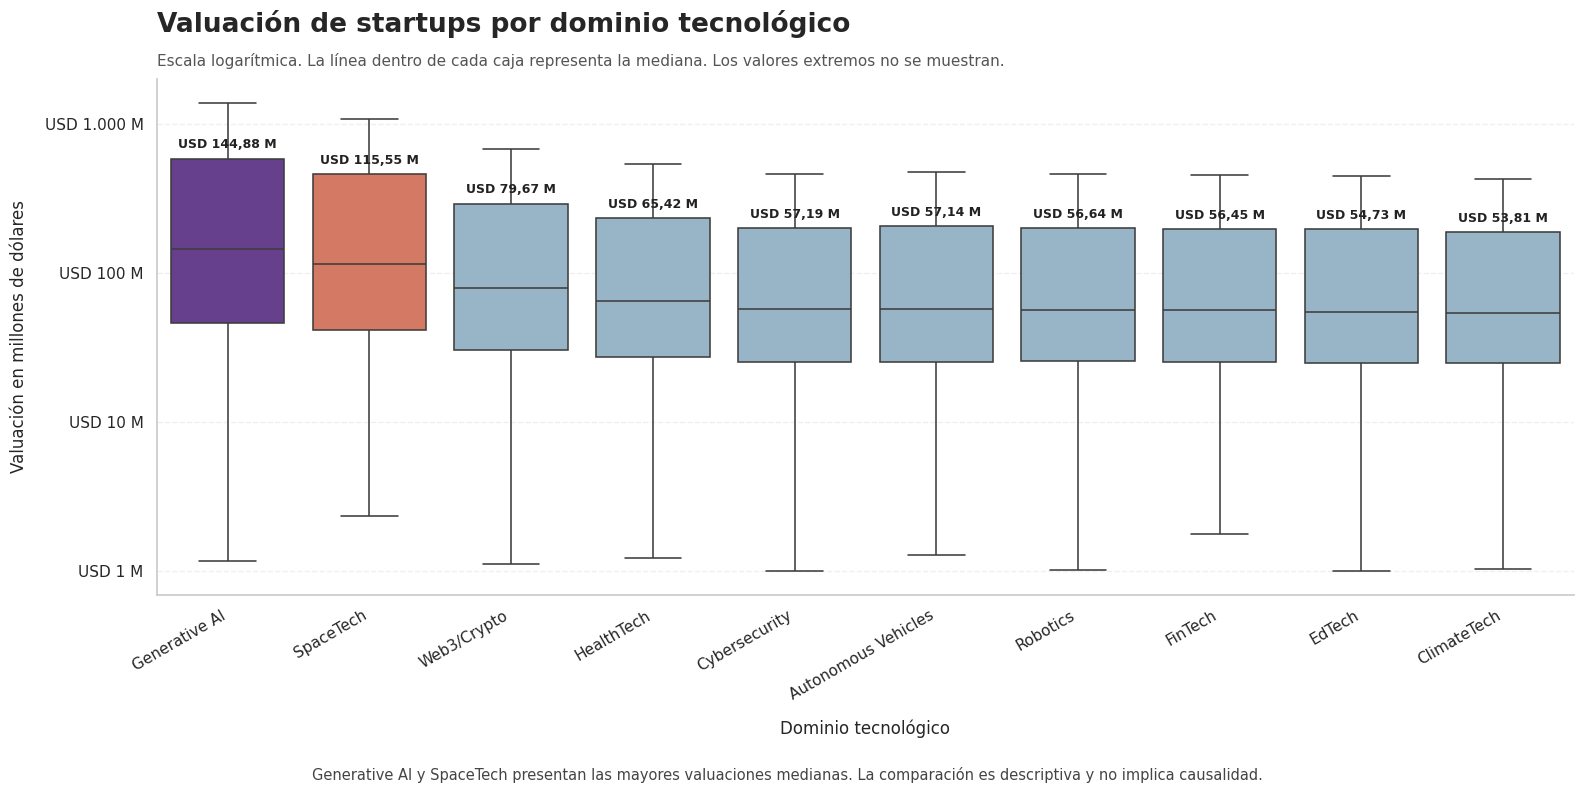

In [ ]:
# Resumen necesario para ordenar y colocar las etiquetas
resumen_dominio = (
    df.groupby("Domain")["Valuation_USD_Millions"]
      .agg(["median"])
      .sort_values("median", ascending=False)
)

orden_dominios = resumen_dominio.index.tolist()

# Colores del gráfico
colores = {
    dominio: (
        "#663399" if dominio == "Generative AI"
        else "#E76F51" if dominio == "SpaceTech"
        else "#8FB7CE"
    )
    for dominio in orden_dominios
}

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(16, 8))

sns.boxplot(
    data=df,
    x="Domain",
    y="Valuation_USD_Millions",
    order=orden_dominios,
    hue="Domain",
    palette=colores,
    legend=False,
    showfliers=False,
    linewidth=1.15,
    ax=ax
)

# Escala logarítmica
ax.set_yscale("log")

# Título y explicación
ax.set_title(
    "Valuación de startups por dominio tecnológico",
    fontsize=19,
    fontweight="bold",
    loc="left",
    pad=34
)

ax.text(
    0,
    1.025,
    "Escala logarítmica. La línea dentro de cada caja representa "
    "la mediana. Los valores extremos no se muestran.",
    transform=ax.transAxes,
    fontsize=11,
    color="#555555"
)

# Nombres de los ejes
ax.set_xlabel(
    "Dominio tecnológico",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "Valuación en millones de dólares",
    fontsize=12,
    labelpad=12
)

# Mostrar USD en lugar de 10¹, 10², etc.
def formato_millones(valor, posicion):
    return f"USD {valor:,.0f} M".replace(",", ".")

ax.yaxis.set_major_formatter(
    FuncFormatter(formato_millones)
)

# Girar los nombres de los dominios
plt.xticks(
    rotation=30,
    ha="right"
)

# Agregar solamente la mediana sobre cada caja
for posicion, dominio in enumerate(orden_dominios):

    mediana = resumen_dominio.loc[dominio, "median"]

    tercer_cuartil = df.loc[
        df["Domain"] == dominio,
        "Valuation_USD_Millions"
    ].quantile(0.75)

    mediana_texto = (
        f"{mediana:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

    ax.text(
        posicion,
        tercer_cuartil * 1.12,
        f"USD {mediana_texto} M",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#222222"
    )

# Mejoras visuales
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

ax.grid(
    axis="x",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Conclusión debajo del gráfico
fig.text(
    0.20,
    0.015,
    "Generative AI y SpaceTech presentan las mayores valuaciones "
    "medianas. La comparación es descriptiva y no implica causalidad.",
    fontsize=10.5,
    color="#444444"
)

plt.tight_layout(
    rect=[0, 0.045, 1, 1]
)

plt.show()

# Observamos que Generative AI y SpaceTech tienden a presentar las mayores valuaciones medianas. Sin embargo, existe una gran variabilidad dentro de todos los dominios,
# lo que sugiere que el sector IA es relevante, pero no es el único factor que determina la valuación de una startup.

# Generative AI y SpaceTech presentan las valuaciones medianas más altas entre los dominios analizados, con aproximadamente USD 144,9 M y USD 115,6 M respectivamente.
# Web3/Crypto se ubica en un nivel intermedio, mientras que el resto de los dominios muestran medianas bastante similares, en torno a USD 54–65 M. Además, la amplitud de
# las cajas indica una alta variabilidad dentro de cada dominio, por lo que estas diferencias deben interpretarse de manera descriptiva y no como una relación causal.

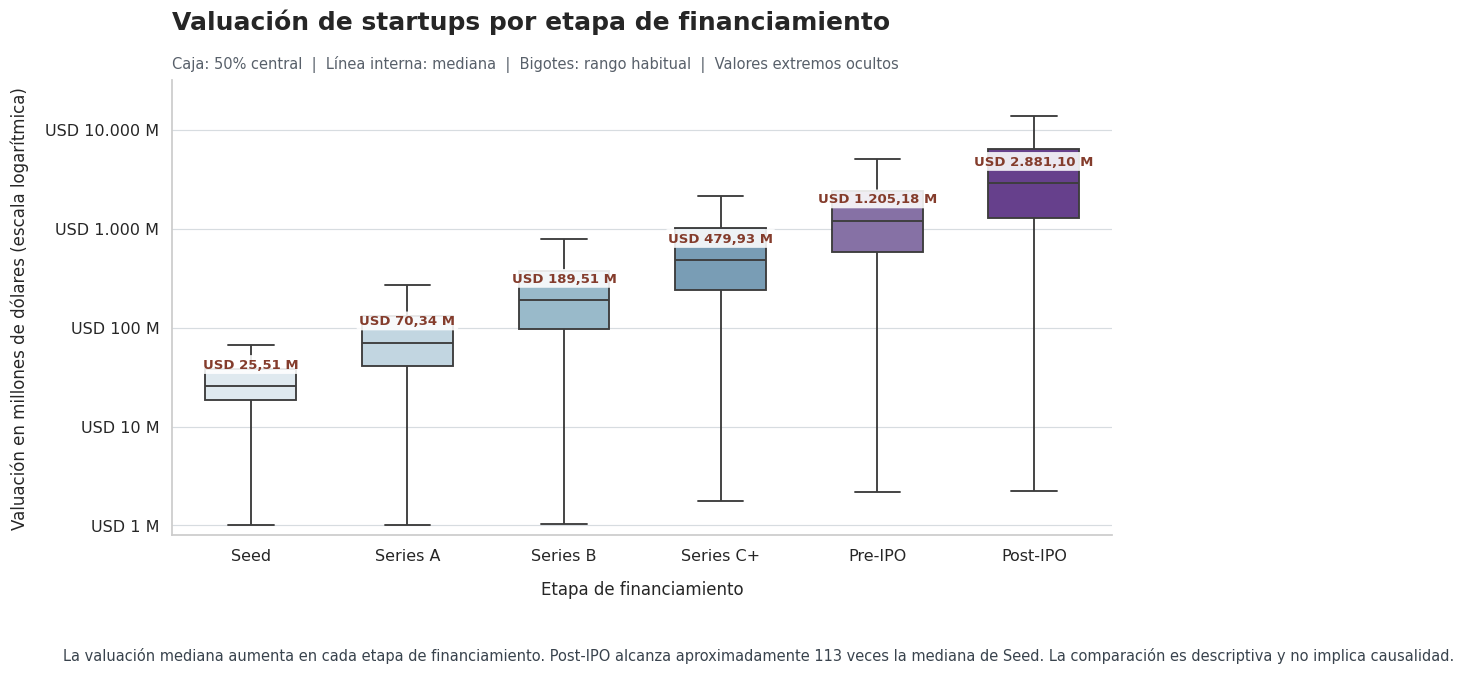

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

stage_order = [
    "Seed",
    "Series A",
    "Series B",
    "Series C+",
    "Pre-IPO",
    "Post-IPO"
]

colores = [
    "#DCEAF2",
    "#BDD7E6",
    "#91BDD2",
    "#6F9FBF",
    "#8468AE",
    "#663399"
]

df_grafico = df.loc[
    df["Funding_Stage"].isin(stage_order)
    & df["Valuation_USD_Millions"].gt(0),
    ["Funding_Stage", "Valuation_USD_Millions"]
].dropna()

medianas = (
    df_grafico
    .groupby("Funding_Stage")["Valuation_USD_Millions"]
    .median()
    .reindex(stage_order)
)

sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(figsize=(12, 7.2))

sns.boxplot(
    data=df_grafico,
    x="Funding_Stage",
    y="Valuation_USD_Millions",
    order=stage_order,
    hue="Funding_Stage",
    hue_order=stage_order,
    palette=colores,
    legend=False,
    showfliers=False,
    width=0.58,
    linewidth=1.35,
    ax=ax
)

ax.set_yscale("log")
ax.set_ylim(0.8, 32000)

def formato_millones(valor, posicion=None):
    if valor >= 1000:
        numero = f"{valor / 1000:,.0f}".replace(",", ".")
        return f"USD {numero}.000 M"

    return f"USD {valor:,.0f} M".replace(",", ".")

ax.yaxis.set_major_locator(
    mticker.LogLocator(base=10)
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(formato_millones)
)

ax.yaxis.set_minor_formatter(
    mticker.NullFormatter()
)

ax.set_title(
    "Valuación de startups por etapa de financiamiento",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=36
)

ax.text(
    0,
    1.025,
    "Caja: 50% central  |  Línea interna: mediana  |  "
    "Bigotes: rango habitual  |  Valores extremos ocultos",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#58606A",
    ha="left"
)

ax.set_xlabel(
    "Etapa de financiamiento",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "Valuación en millones de dólares (escala logarítmica)",
    fontsize=12,
    labelpad=12
)

for posicion, valor in enumerate(medianas.values):

    etiqueta = (
        f"USD {valor:,.2f} M"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

    ax.annotate(
        etiqueta,
        (posicion, valor),
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color="#843C2C",
        bbox={
            "boxstyle": "round,pad=0.22",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.88
        },
        zorder=6
    )

ax.grid(
    axis="y",
    which="major",
    color="#D7DCE0",
    linewidth=0.85
)

ax.grid(axis="x", visible=False)
sns.despine(ax=ax)

fig.text(
    0.10,
    0.02,
    "La valuación mediana aumenta en cada etapa de financiamiento. "
    "Post-IPO alcanza aproximadamente 113 veces la mediana de Seed. "
    "La comparación es descriptiva y no implica causalidad.",
    ha="left",
    fontsize=10.5,
    color="#39434D"
)

plt.tight_layout(
    rect=(0.04, 0.08, 0.99, 0.95)
)

plt.show()

# Conclusión: Se observa una relación creciente entre la etapa de financiamiento y la valuación: las startups en fases más avanzadas presentan valuaciones medianas considerablemente
# mayores. A su vez, la dispersión aumenta en etapas avanzadas, evidenciando una mayor heterogeneidad entre empresas.

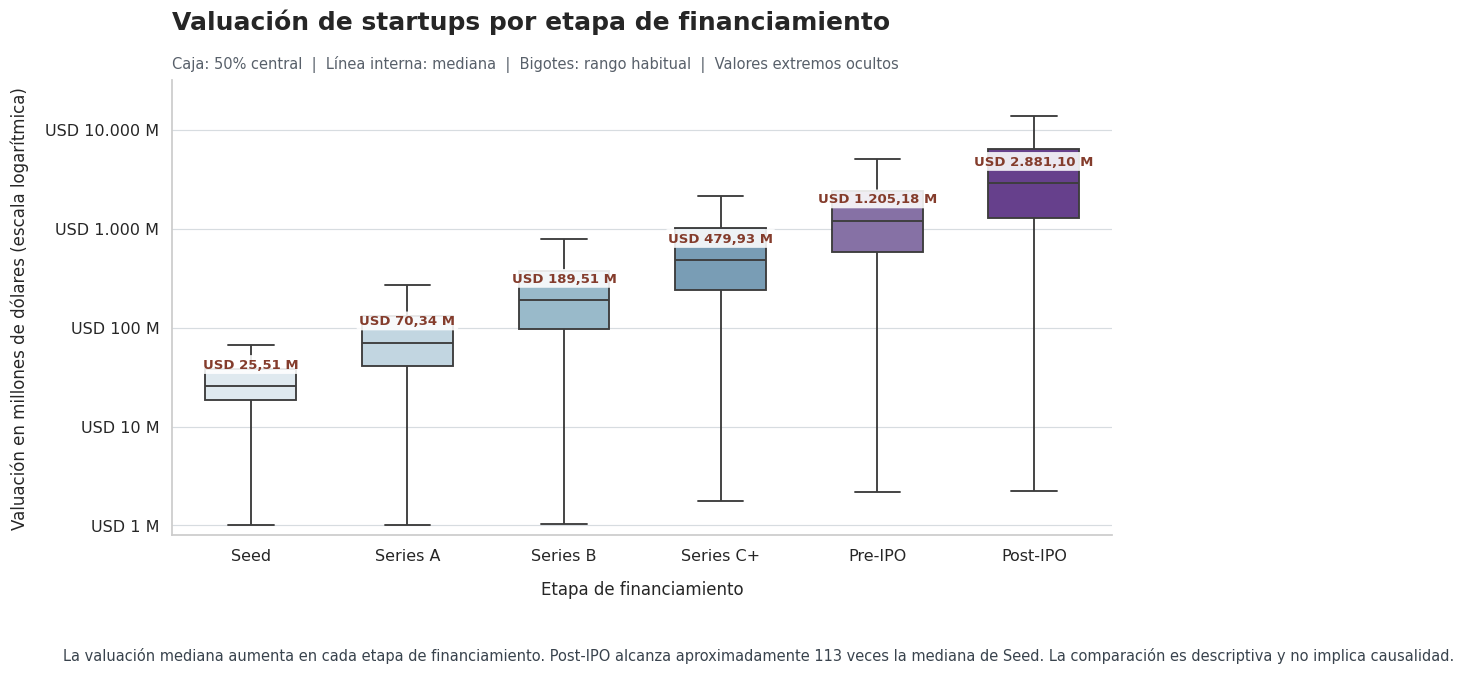

In [ ]:
stage_order = [
    "Seed",
    "Series A",
    "Series B",
    "Series C+",
    "Pre-IPO",
    "Post-IPO"
]

colores = [
    "#DCEAF2",
    "#BDD7E6",
    "#91BDD2",
    "#6F9FBF",
    "#8468AE",
    "#663399"
]

df_grafico = df.loc[
    df["Funding_Stage"].isin(stage_order)
    & df["Valuation_USD_Millions"].gt(0),
    ["Funding_Stage", "Valuation_USD_Millions"]
].dropna()

medianas = (
    df_grafico
    .groupby("Funding_Stage")["Valuation_USD_Millions"]
    .median()
    .reindex(stage_order)
)

sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(figsize=(12, 7.2))

sns.boxplot(
    data=df_grafico,
    x="Funding_Stage",
    y="Valuation_USD_Millions",
    order=stage_order,
    hue="Funding_Stage",
    hue_order=stage_order,
    palette=colores,
    legend=False,
    showfliers=False,
    width=0.58,
    linewidth=1.35,
    ax=ax
)

ax.set_yscale("log")
ax.set_ylim(0.8, 32000)

def formato_millones(valor, posicion=None):
    if valor >= 1000:
        numero = f"{valor / 1000:,.0f}".replace(",", ".")
        return f"USD {numero}.000 M"

    return f"USD {valor:,.0f} M".replace(",", ".")

ax.yaxis.set_major_locator(
    mticker.LogLocator(base=10)
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(formato_millones)
)

ax.yaxis.set_minor_formatter(
    mticker.NullFormatter()
)

ax.set_title(
    "Valuación de startups por etapa de financiamiento",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=36
)

ax.text(
    0,
    1.025,
    "Caja: 50% central  |  Línea interna: mediana  |  "
    "Bigotes: rango habitual  |  Valores extremos ocultos",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#58606A",
    ha="left"
)

ax.set_xlabel(
    "Etapa de financiamiento",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "Valuación en millones de dólares (escala logarítmica)",
    fontsize=12,
    labelpad=12
)

for posicion, valor in enumerate(medianas.values):

    etiqueta = (
        f"USD {valor:,.2f} M"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

    ax.annotate(
        etiqueta,
        (posicion, valor),
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color="#843C2C",
        bbox={
            "boxstyle": "round,pad=0.22",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.88
        },
        zorder=6
    )

ax.grid(
    axis="y",
    which="major",
    color="#D7DCE0",
    linewidth=0.85
)

ax.grid(axis="x", visible=False)
sns.despine(ax=ax)

fig.text(
    0.10,
    0.02,
    "La valuación mediana aumenta en cada etapa de financiamiento. "
    "Post-IPO alcanza aproximadamente 113 veces la mediana de Seed. "
    "La comparación es descriptiva y no implica causalidad.",
    ha="left",
    fontsize=10.5,
    color="#39434D"
)

plt.tight_layout(
    rect=(0.04, 0.08, 0.99, 0.95)
)

plt.show()

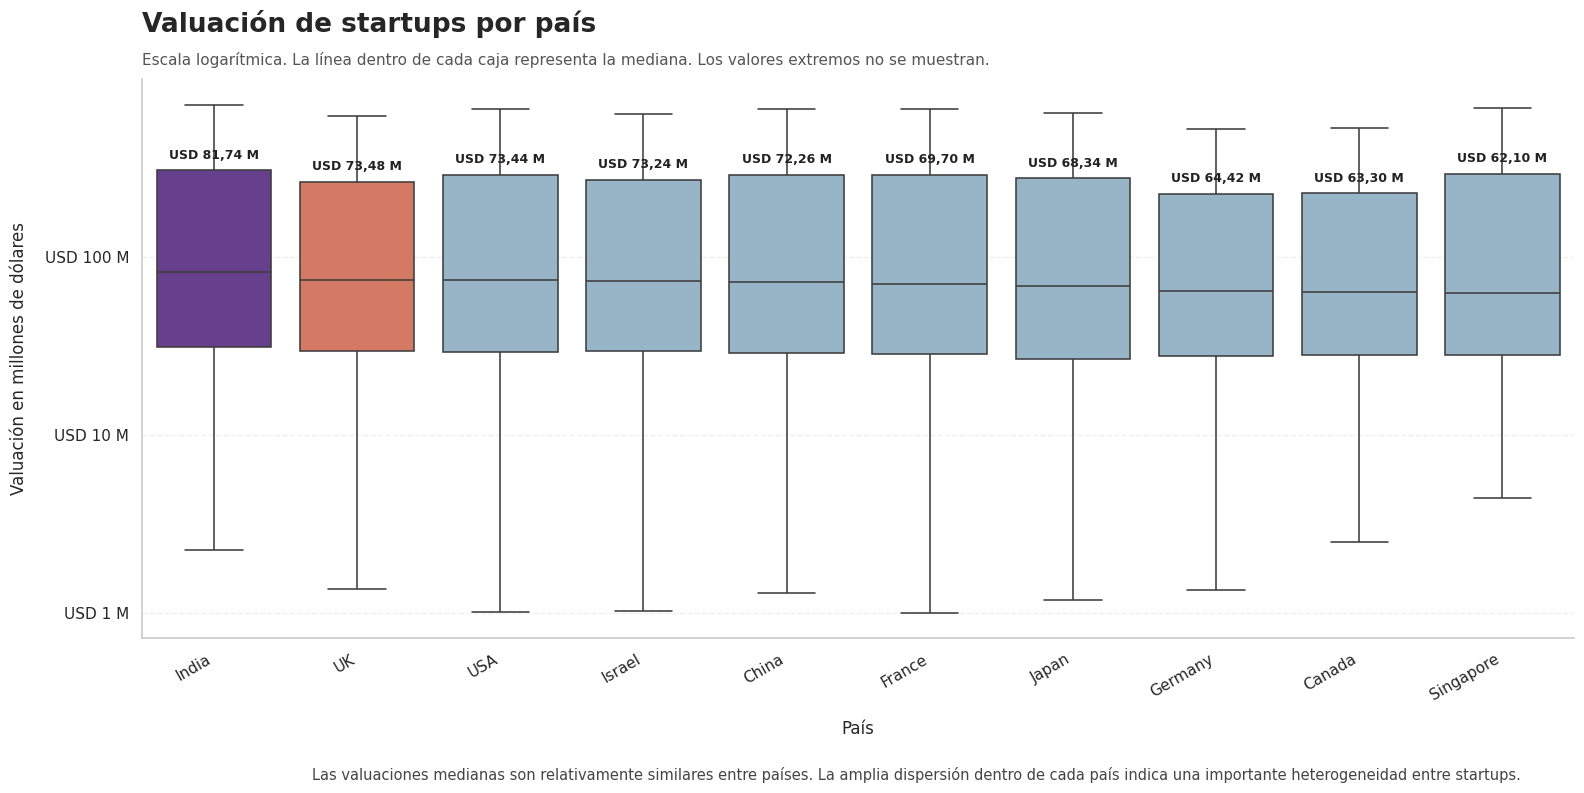

In [ ]:
resumen_pais = (
    df.groupby("Country")["Valuation_USD_Millions"]
      .agg(["median"])
      .sort_values("median", ascending=False)
)

orden_paises = resumen_pais.index.tolist()

# Colores del gráfico:
# destacamos los dos países con mayor mediana
primer_pais = orden_paises[0]
segundo_pais = orden_paises[1]

colores = {
    pais: (
        "#663399" if pais == primer_pais
        else "#E76F51" if pais == segundo_pais
        else "#8FB7CE"
    )
    for pais in orden_paises
}

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(16, 8))

sns.boxplot(
    data=df,
    x="Country",
    y="Valuation_USD_Millions",
    order=orden_paises,
    hue="Country",
    palette=colores,
    legend=False,
    showfliers=False,
    linewidth=1.15,
    ax=ax
)

# Escala logarítmica
ax.set_yscale("log")

# Título y explicación
ax.set_title(
    "Valuación de startups por país",
    fontsize=19,
    fontweight="bold",
    loc="left",
    pad=34
)

ax.text(
    0,
    1.025,
    "Escala logarítmica. La línea dentro de cada caja representa "
    "la mediana. Los valores extremos no se muestran.",
    transform=ax.transAxes,
    fontsize=11,
    color="#555555"
)

# Nombres de los ejes
ax.set_xlabel(
    "País",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "Valuación en millones de dólares",
    fontsize=12,
    labelpad=12
)

# Mostrar USD en lugar de 10¹, 10², etc.
def formato_millones(valor, posicion):
    return f"USD {valor:,.0f} M".replace(",", ".")

ax.yaxis.set_major_formatter(
    FuncFormatter(formato_millones)
)

# Girar los nombres de los países
plt.xticks(
    rotation=30,
    ha="right"
)

# Agregar solamente la mediana sobre cada caja
for posicion, pais in enumerate(orden_paises):

    mediana = resumen_pais.loc[pais, "median"]

    tercer_cuartil = df.loc[
        df["Country"] == pais,
        "Valuation_USD_Millions"
    ].quantile(0.75)

    mediana_texto = (
        f"{mediana:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

    ax.text(
        posicion,
        tercer_cuartil * 1.12,
        f"USD {mediana_texto} M",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#222222"
    )

# Mejoras visuales
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

ax.grid(
    axis="x",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Conclusión debajo del gráfico
fig.text(
    0.20,
    0.015,
    "Las valuaciones medianas son relativamente similares entre países. "
    "La amplia dispersión dentro de cada país indica una importante "
    "heterogeneidad entre startups.",
    fontsize=10.5,
    color="#444444"
)

plt.tight_layout(
    rect=[0, 0.045, 1, 1]
)

plt.show()

# Las valuaciones medianas son relativamente similares entre los países analizados y presentan un alto grado de solapamiento.
# La amplia dispersión dentro de cada país sugiere que la ubicación geográfica, por sí sola, no explica las diferencias de valuación.

## 8. Correlaciones y relaciones numéricas

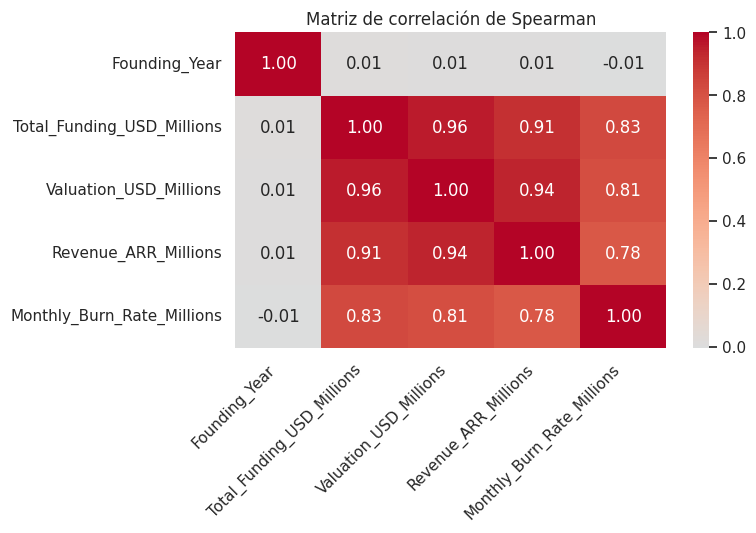

In [ ]:
numeric_cols = ["Founding_Year", "Total_Funding_USD_Millions", "Valuation_USD_Millions", "Revenue_ARR_Millions", "Monthly_Burn_Rate_Millions"]

pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")
"""print("Pearson")
display(pearson_corr.round(3))
print("Spearman")
display(spearman_corr.round(3))"""

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

# Las variables financieras presentan correlaciones positivas fuertes entre sí. La relación más elevada se observa entre financiamiento total y valuación (≈0,96).
# También se destacan las asociaciones entre valuación, revenue y burn rate. En cambio, el año de fundación presenta correlaciones cercanas a cero, por lo que no muestra
# una relación significativa con las principales métricas financieras. Los resultados de Pearson y Spearman son consistentes entre sí.

# Mostramos Spearman porque no asumimos linealidad entre variables financieras por tener multiples factores influyentes. Spearman más robusta frente a outliers.

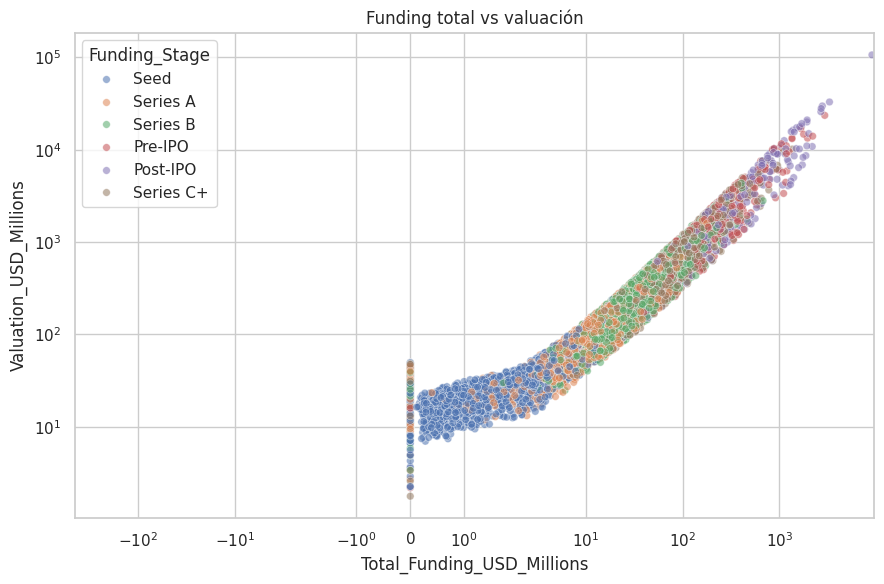

In [ ]:
sample_plot = df.sample(min(6000, len(df)), random_state = random_state)

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=sample_plot,
    x="Total_Funding_USD_Millions",
    y="Valuation_USD_Millions",
    hue="Funding_Stage", alpha=0.55, s=30
)
plt.xscale("symlog")
plt.yscale("log")
plt.title("Funding total vs valuación")
plt.tight_layout()
plt.show()

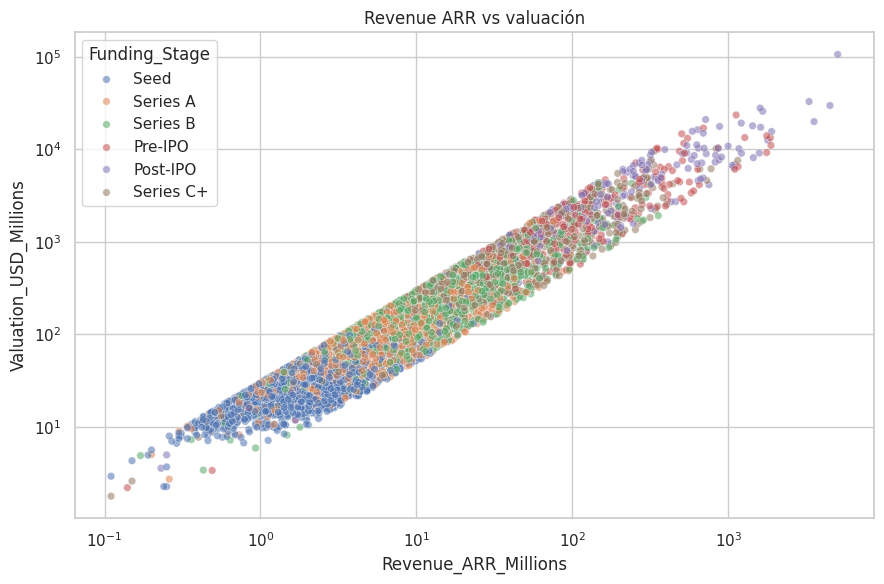

In [ ]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=sample_plot,
    x="Revenue_ARR_Millions",
    y="Valuation_USD_Millions",
    hue="Funding_Stage", alpha=0.55, s=30
)
plt.xscale("log")
plt.yscale("log")
plt.title("Revenue ARR vs valuación")
plt.tight_layout()
plt.show()

**#Esta relación es la métrica clave para entender si una empresa está sobrevalorada o subvalorada respecto a lo que realmente factura.#** Luciana #podriamos agregar una linea de tendencia#

## 9. Contraste de hipótesis

In [ ]:
rho_funding, p_funding = spearmanr(df["Total_Funding_USD_Millions"], df["Valuation_USD_Millions"])
rho_arr, p_arr = spearmanr(df["Revenue_ARR_Millions"], df["Valuation_USD_Millions"])

stage_groups = [g["Valuation_USD_Millions"].values for _, g in df.groupby("Funding_Stage")]
kw_stage, p_kw_stage = kruskal(*stage_groups)

domain_groups = [g["Valuation_USD_Millions"].values for _, g in df.groupby("Domain")]
kw_domain, p_kw_domain = kruskal(*domain_groups)

hypothesis_results = pd.DataFrame({
    "Hipótesis": [
        "Funding asociado a valuación",
        "ARR asociado a valuación",
        "Valuación difiere por Funding Stage",
        "Valuación difiere por Domain"
    ],
    "Estadístico": [rho_funding, rho_arr, kw_stage, kw_domain],
    "p_value": [p_funding, p_arr, p_kw_stage, p_kw_domain]
})
hypothesis_results["Significativo_5pct"] = hypothesis_results["p_value"] < 0.05
display(hypothesis_results)

,Hipótesis,Estadístico,p_value,Significativo_5pct
0,Funding asociado a valuación,0.959628,0.000000e+00,True
1,ARR asociado a valuación,0.942634,0.000000e+00,True
2,Valuación difiere por Funding Stage,15713.233029,0.000000e+00,True
3,Valuación difiere por Domain,1160.849708,3.425924e-244,True


## 10. Preparación para Machine Learning

### Fix: Re-defining `df_model` and its features

The previous cell using `df_model` (cell `d0994b83`) encountered a `NameError` because `df_model` was not defined. This cell re-creates `df_model` and its engineered features, ensuring dependent operations proceed without errors.

In [ ]:
# Re-create df_model and its features, assuming this cell might be run out of order
df_model = df.copy()
df_model["Startup_Age"] = 2026 - df_model["Founding_Year"]
df_model["Annual_Burn_Millions"] = df_model["Monthly_Burn_Rate_Millions"] * 12
EPS = 1e-6 # Ensure EPS is defined

df_model["Revenue_Burn_Ratio"] = (
    df_model["Revenue_ARR_Millions"] / (df_model["Annual_Burn_Millions"] + EPS)
)
df_model["Revenue_Funding_Ratio"] = (
    df_model["Revenue_ARR_Millions"] / (df_model["Total_Funding_USD_Millions"] + EPS)
)

In [ ]:
features = [
    "Domain", "Country", "City", "Funding_Stage",
    "Startup_Age", "Total_Funding_USD_Millions",
    "Revenue_ARR_Millions", "Monthly_Burn_Rate_Millions",
    "Annual_Burn_Millions", "Revenue_Burn_Ratio", "Revenue_Funding_Ratio"
]
target = "Valuation_USD_Millions"

X = df_model[features].copy()
y = df_model[target].copy()
y_log = np.log1p(y)

categorical_features = ["Domain", "Country", "City", "Funding_Stage"]
numeric_features = [
    "Startup_Age", "Total_Funding_USD_Millions", "Revenue_ARR_Millions",
    "Monthly_Burn_Rate_Millions", "Annual_Burn_Millions",
    "Revenue_Burn_Ratio", "Revenue_Funding_Ratio"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.20, random_state= random_state
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (20000, 11)
Test: (5000, 11)


## 11. Entrenamiento y comparación de modelos

In [ ]:
# Modelo de regresión lineal
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Entrenamiento
linear_pipeline.fit(X_train, y_train_log)

# Predicciones
linear_pred_log = linear_pipeline.predict(X_test)
linear_pred_original = np.clip(
    np.expm1(linear_pred_log),
    0,
    None
)

# Valores reales en escala original
y_test_original = np.expm1(y_test_log)

# Métricas
linear_results = pd.DataFrame([{
    "Modelo": "Linear Regression",
    "MAE_USD_Millions": mean_absolute_error(
        y_test_original,
        linear_pred_original
    ),
    "RMSE_USD_Millions": np.sqrt(
        mean_squared_error(
            y_test_original,
            linear_pred_original
        )
    ),
    "R2_original": r2_score(
        y_test_original,
        linear_pred_original
    ),
    "R2_log": r2_score(
        y_test_log,
        linear_pred_log
    )
}])

display(linear_results)

,Modelo,MAE_USD_Millions,RMSE_USD_Millions,R2_original,R2_log
0,Linear Regression,28663.13982,1.996530e+06,-849850.551157,0.766506


In [ ]:
# Modelo Random Forest
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=random_state
    ))
])

# Entrenamiento
random_forest_pipeline.fit(X_train, y_train_log)

# Predicciones
rf_pred_log = random_forest_pipeline.predict(X_test)
rf_pred_original = np.clip(
    np.expm1(rf_pred_log),
    0,
    None
)

# Valores reales en escala original
y_test_original = np.expm1(y_test_log)

# Métricas
random_forest_results = pd.DataFrame([{
    "Modelo": "Random Forest",
    "MAE_USD_Millions": mean_absolute_error(
        y_test_original,
        rf_pred_original
    ),
    "RMSE_USD_Millions": np.sqrt(
        mean_squared_error(
            y_test_original,
            rf_pred_original
        )
    ),
    "R2_original": r2_score(
        y_test_original,
        rf_pred_original
    ),
    "R2_log": r2_score(
        y_test_log,
        rf_pred_log
    )
}])

display(random_forest_results)

,Modelo,MAE_USD_Millions,RMSE_USD_Millions,R2_original,R2_log
0,Random Forest,112.159633,687.123109,0.899339,0.971618


In [ ]:
# Modelo Gradient Boosting
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=random_state
    ))
])

# Entrenamiento
gradient_boosting_pipeline.fit(X_train, y_train_log)

# Predicciones
gb_pred_log = gradient_boosting_pipeline.predict(X_test)
gb_pred_original = np.clip(
    np.expm1(gb_pred_log),
    0,
    None
)

# Valores reales en escala original
y_test_original = np.expm1(y_test_log)

# Métricas
gradient_boosting_results = pd.DataFrame([{
    "Modelo": "Gradient Boosting",
    "MAE_USD_Millions": mean_absolute_error(
        y_test_original,
        gb_pred_original
    ),
    "RMSE_USD_Millions": np.sqrt(
        mean_squared_error(
            y_test_original,
            gb_pred_original
        )
    ),
    "R2_original": r2_score(
        y_test_original,
        gb_pred_original
    ),
    "R2_log": r2_score(
        y_test_log,
        gb_pred_log
    )
}])

display(gradient_boosting_results)

,Modelo,MAE_USD_Millions,RMSE_USD_Millions,R2_original,R2_log
0,Gradient Boosting,111.266318,768.104458,0.874214,0.972993


In [ ]:
#Comparación de resultados de los 3 modelos

results_df = pd.concat([
    linear_results,
    random_forest_results,
    gradient_boosting_results
], ignore_index=True)

results_df = results_df.sort_values(
    "R2_log",
    ascending=False
)

display(results_df)

,Modelo,MAE_USD_Millions,RMSE_USD_Millions,R2_original,R2_log
2,Gradient Boosting,111.266318,7.681045e+02,0.874214,0.972993
1,Random Forest,112.159633,6.871231e+02,0.899339,0.971618
0,Linear Regression,28663.139820,1.996530e+06,-849850.551157,0.766506


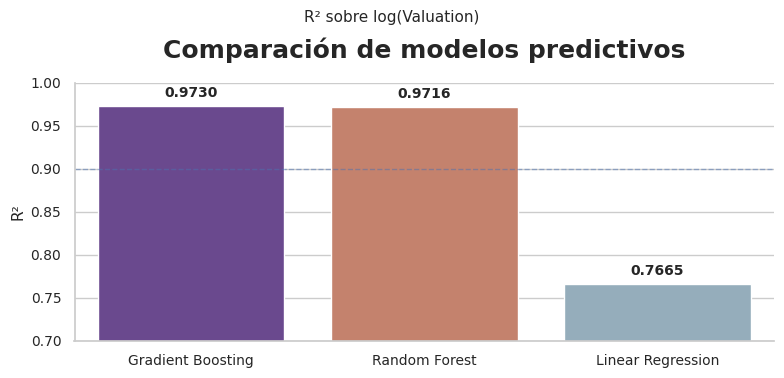

In [ ]:
plt.figure(figsize=(8,4))

ax = sns.barplot(
    data=results_df,
    x="Modelo",
    y="R2_log",
    palette=["#6A3D9A", "#D27A5F", "#8FAFC1"]
)

# Título y subtítulo
plt.title(
    "Comparación de modelos predictivos",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.suptitle(
    "R² sobre log(Valuation)",
    fontsize=11,
    y=0.94
)

# Etiquetas de los ejes
plt.xlabel("")
plt.ylabel("R²", fontsize=11)

# Mostrar valores sobre cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=4,
        fontsize=10,
        fontweight="bold"
    )

# Ajustar eje Y para resaltar diferencias
plt.ylim(0.70, 1.00)

# Línea horizontal de referencia
plt.axhline(
    0.90,
    linestyle="--",
    linewidth=1,
    alpha=0.5
)

# Mejorar estética
sns.despine()

plt.xticks(
    rotation=0,
    fontsize=10
)

plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

## 12. Mejor modelo: real vs predicho

Mejor modelo: Gradient Boosting


,Real,Predicho
6868,22.57,21.281766
24016,33.89,30.556576
9668,181.50,152.151356
13640,74.44,80.878364
14018,6422.87,4747.855704


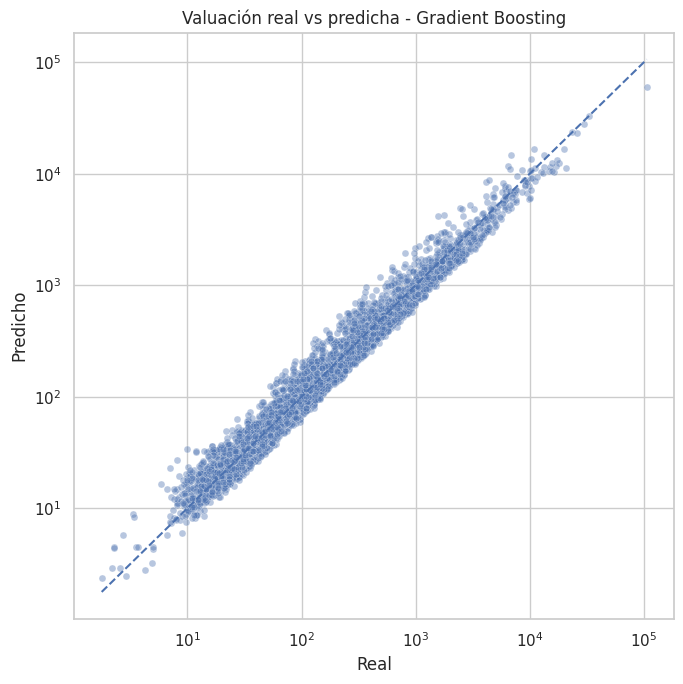

In [ ]:
best_model_name = results_df.iloc[0]["Modelo"]
best_pipeline = fitted_models[best_model_name]
print("Mejor modelo:", best_model_name)

best_pred_log = best_pipeline.predict(X_test)
best_pred_original = np.clip(np.expm1(best_pred_log), 0, None)
plot_predictions = pd.DataFrame({"Real": y_test_original, "Predicho": best_pred_original})
display(plot_predictions.head())

plt.figure(figsize=(7,7))
sns.scatterplot(data=plot_predictions, x="Real", y="Predicho", alpha=0.4, s=25)
max_val = max(plot_predictions["Real"].max(), plot_predictions["Predicho"].max())
min_positive = max(0.01, min(
    plot_predictions.loc[plot_predictions["Real"]>0, "Real"].min(),
    plot_predictions.loc[plot_predictions["Predicho"]>0, "Predicho"].min()
))
plt.plot([min_positive, max_val], [min_positive, max_val], linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Valuación real vs predicha - {best_model_name}")
plt.tight_layout()
plt.show()

## 13. Validación cruzada

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
cv_scores = cross_val_score(best_pipeline, X, y_log, cv=cv, scoring="r2", n_jobs=-1)
cv_df = pd.DataFrame({"Fold": range(1,6), "R2_log": cv_scores})
display(cv_df)
print(f"R² medio: {cv_scores.mean():.4f}")
print(f"Desvío: {cv_scores.std():.4f}")

,Fold,R2_log
0,1,0.972993
1,2,0.973163
2,3,0.973051
3,4,0.973898
4,5,0.974184


R² medio: 0.9735
Desvío: 0.0005


## 14. Análisis de residuos y errores

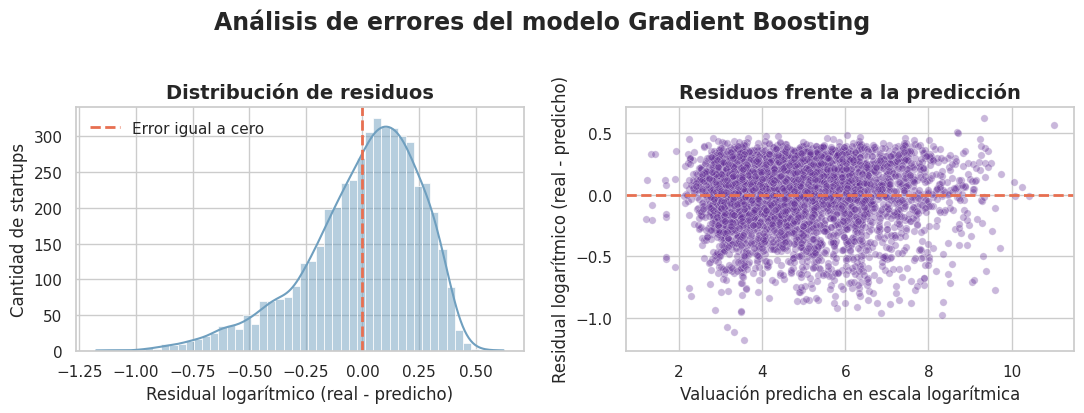

,Métrica,USD_Millones
0,Error absoluto mediano,12.01
1,Error absoluto promedio,111.27
2,Percentil 90 del error,197.43
3,Mayor error absoluto,46047.10


,Casos,MAE,Error_Mediano,Error_Porcentual_Mediano
Segmento_Valuacion,,,,
Hasta USD 100 M,2760,8.00,4.83,15.43
USD 100 a 500 M,1385,54.49,35.72,18.28
USD 500 a 2.000 M,593,228.02,157.66,18.59
Más de USD 2.000 M,262,1234.97,636.24,19.45


,Company_ID,Domain,Funding_Stage,Real_USD_Millions,Predicho_USD_Millions,Residual,Abs_Error,Error_Porcentual,Tipo_Error
1465,5C6B32DE,Generative AI,Post-IPO,106376.86,60329.76,46047.10,46047.10,43.29,Subestimación
1205,3C679C75,HealthTech,Post-IPO,21012.62,11261.88,9750.74,9750.74,46.40,Subestimación
12,07F37A5A,ClimateTech,Post-IPO,6856.82,14900.49,-8043.67,8043.67,117.31,Sobreestimación
656,3B79F10D,HealthTech,Post-IPO,16333.05,10373.09,5959.96,5959.96,36.49,Subestimación
3240,7AA5223E,ClimateTech,Post-IPO,10837.05,16674.44,-5837.39,5837.39,53.87,Sobreestimación
1803,A09ACAE7,Robotics,Post-IPO,6400.62,11849.95,-5449.33,5449.33,85.14,Sobreestimación
763,68267664,Generative AI,Post-IPO,17966.67,12585.24,5381.43,5381.43,29.95,Subestimación
2065,436F576A,Generative AI,Pre-IPO,16981.24,11657.11,5324.13,5324.13,31.35,Subestimación
3914,01735230,SpaceTech,Post-IPO,15696.41,10555.55,5140.86,5140.86,32.75,Subestimación
2763,AA104563,Generative AI,Pre-IPO,4435.68,8844.17,-4408.49,4408.49,99.39,Sobreestimación


In [ ]:
# Residuo = valor real - valor predicho
residuals_original = (
    y_test_original.to_numpy() - best_pred_original
)

residuals_log = (
    y_test_log.to_numpy() - best_pred_log
)

# Índices originales del conjunto de prueba
test_index = y_test_original.index

# Tabla detallada de errores
error_df = pd.DataFrame({
    "Company_ID": df_model.loc[
        test_index, "Company_ID"
    ].to_numpy(),

    "Domain": df_model.loc[
        test_index, "Domain"
    ].to_numpy(),

    "Funding_Stage": df_model.loc[
        test_index, "Funding_Stage"
    ].to_numpy(),

    "Real_USD_Millions": y_test_original.to_numpy(),

    "Predicho_USD_Millions": best_pred_original,

    "Residual": residuals_original,

    "Abs_Error": np.abs(residuals_original)
})

# Error porcentual
error_df["Error_Porcentual"] = (
    error_df["Abs_Error"]
    / error_df["Real_USD_Millions"]
    * 100
)

# Tipo de error
error_df["Tipo_Error"] = np.where(
    error_df["Residual"] > 0,
    "Subestimación",
    "Sobreestimación"
)

# ==========================================================
# GRÁFICOS
# ==========================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4)
)

# ----------------------------------------------------------
# Gráfico 1: distribución de residuos en escala logarítmica
# ----------------------------------------------------------

sns.histplot(
    residuals_log,
    bins=50,
    kde=True,
    color="#6F9FBF",
    ax=axes[0]
)

axes[0].axvline(
    0,
    color="#E76F51",
    linestyle="--",
    linewidth=2,
    label="Error igual a cero"
)

axes[0].set_title(
    "Distribución de residuos",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Residual logarítmico (real - predicho)"
)

axes[0].set_ylabel(
    "Cantidad de startups"
)

axes[0].legend(frameon=False)

# ----------------------------------------------------------
# Gráfico 2: residuos frente a valores predichos
# ----------------------------------------------------------

sns.scatterplot(
    x=best_pred_log,
    y=residuals_log,
    alpha=0.35,
    s=28,
    color="#663399",
    ax=axes[1]
)

axes[1].axhline(
    0,
    color="#E76F51",
    linestyle="--",
    linewidth=2
)

axes[1].set_title(
    "Residuos frente a la predicción",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Valuación predicha en escala logarítmica"
)

axes[1].set_ylabel(
    "Residual logarítmico (real - predicho)"
)

plt.suptitle(
    f"Análisis de errores del modelo {best_model_name}",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

# ==========================================================
# RESUMEN DE ERRORES
# ==========================================================

resumen_errores = pd.DataFrame({
    "Métrica": [
        "Error absoluto mediano",
        "Error absoluto promedio",
        "Percentil 90 del error",
        "Mayor error absoluto"
    ],

    "USD_Millones": [
        error_df["Abs_Error"].median(),
        error_df["Abs_Error"].mean(),
        error_df["Abs_Error"].quantile(0.90),
        error_df["Abs_Error"].max()
    ]
})

resumen_errores["USD_Millones"] = (
    resumen_errores["USD_Millones"].round(2)
)

display(resumen_errores)

# ==========================================================
# ERRORES SEGÚN EL TAMAÑO DE LA STARTUP
# ==========================================================

error_df["Segmento_Valuacion"] = pd.cut(
    error_df["Real_USD_Millions"],
    bins=[0, 100, 500, 2000, np.inf],
    labels=[
        "Hasta USD 100 M",
        "USD 100 a 500 M",
        "USD 500 a 2.000 M",
        "Más de USD 2.000 M"
    ],
    include_lowest=True
)

errores_por_segmento = (
    error_df
    .groupby(
        "Segmento_Valuacion",
        observed=False
    )
    .agg(
        Casos=("Real_USD_Millions", "size"),
        MAE=("Abs_Error", "mean"),
        Error_Mediano=("Abs_Error", "median"),
        Error_Porcentual_Mediano=(
            "Error_Porcentual",
            "median"
        )
    )
    .round(2)
)

display(errores_por_segmento)

# ==========================================================
# 10 STARTUPS CON MAYOR ERROR
# ==========================================================

columnas_mostrar = [
    "Company_ID",
    "Domain",
    "Funding_Stage",
    "Real_USD_Millions",
    "Predicho_USD_Millions",
    "Residual",
    "Abs_Error",
    "Error_Porcentual",
    "Tipo_Error"
]

top_10_errores = (
    error_df
    .sort_values(
        "Abs_Error",
        ascending=False
    )
    [columnas_mostrar]
    .head(10)
    .round(2)
)

display(top_10_errores)

## 16. Clustering

,k,silhouette
0,2,0.483350
1,3,0.367280
2,4,0.362866
3,5,0.335623
4,6,0.339340


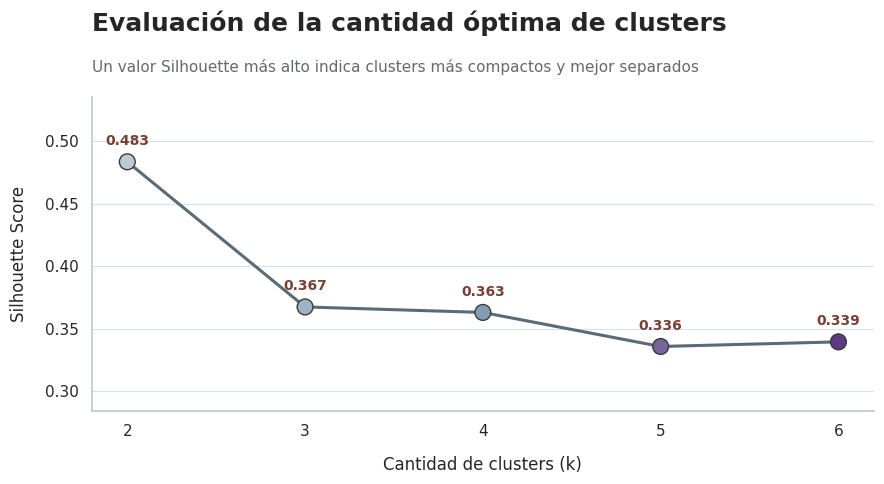

In [ ]:
# Variables utilizadas para crear los clusters
cluster_features = [
    "Total_Funding_USD_Millions",
    "Valuation_USD_Millions",
    "Revenue_ARR_Millions",
    "Monthly_Burn_Rate_Millions",
    "Startup_Age"
]

# Crear dataset para clustering
cluster_df = df_model[cluster_features].copy()

# Transformación logarítmica de las variables monetarias
for col in cluster_features[:-1]:
    cluster_df[col] = np.log1p(cluster_df[col])

# Estandarización de las variables
cluster_scaled = StandardScaler().fit_transform(cluster_df)

# Selección de una muestra para calcular Silhouette Score
rng = np.random.default_rng(random_state)

sample_idx = rng.choice(
    len(cluster_scaled),
    size=min(5000, len(cluster_scaled)),
    replace=False
)

# Evaluación de diferentes cantidades de clusters
silhouette_results = []

for k in range(2, 7):

    km = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )

    labels = km.fit_predict(cluster_scaled)

    sil = silhouette_score(
        cluster_scaled[sample_idx],
        labels[sample_idx]
    )

    silhouette_results.append({
        "k": k,
        "silhouette": sil
    })

# Tabla de resultados
silhouette_df = pd.DataFrame(silhouette_results)

display(silhouette_df)

#Gráfico

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 5))

# Paleta azul-violeta
colors = sns.color_palette(
    ["#BCCAD4", "#9EB3C3", "#829CB1", "#76649A", "#5D3B82"]
)

# Línea
ax.plot(
    silhouette_df["k"],
    silhouette_df["silhouette"],
    color="#596A78",
    linewidth=2.2,
    zorder=2
)

# Puntos con colores graduales
ax.scatter(
    silhouette_df["k"],
    silhouette_df["silhouette"],
    s=130,
    c=colors,
    edgecolor="#3A3A3A",
    linewidth=1,
    zorder=3
)

# Etiqueta sobre cada punto
for _, row in silhouette_df.iterrows():

    ax.annotate(
        f"{row['silhouette']:.3f}",
        xy=(row["k"], row["silhouette"]),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#7A4035"
    )

# Título principal
ax.set_title(
    "Evaluación de la cantidad óptima de clusters",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=48,
    color="#262626"
)

# Subtítulo
ax.text(
    0,
    1.08,
    "Un valor Silhouette más alto indica clusters más compactos y mejor separados",
    transform=ax.transAxes,
    fontsize=11,
    color="#626A70"
)

# Etiquetas de los ejes
ax.set_xlabel(
    "Cantidad de clusters (k)",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "Silhouette Score",
    fontsize=12,
    labelpad=12
)

# Mostrar solamente valores enteros de k
ax.set_xticks(silhouette_df["k"])

# Espacio adicional para las etiquetas
margen = max(
    (silhouette_df["silhouette"].max()
     - silhouette_df["silhouette"].min()) * 0.35,
    0.02
)

ax.set_ylim(
    silhouette_df["silhouette"].min() - margen,
    silhouette_df["silhouette"].max() + margen
)

# Diseño de la cuadrícula
ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.8,
    color="#D5DCE1",
    alpha=0.9
)

ax.grid(
    axis="x",
    visible=False
)

# Eliminar bordes innecesarios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#C5C9CC")
ax.spines["bottom"].set_color("#C5C9CC")

plt.tight_layout()
plt.show()

Mejor k: 2


,Cantidad,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Startup_Age
Cluster,,,,,,
0,7663,76.11,558.20,37.79,4.11,6.0
1,17337,3.60,39.53,2.59,0.53,7.0


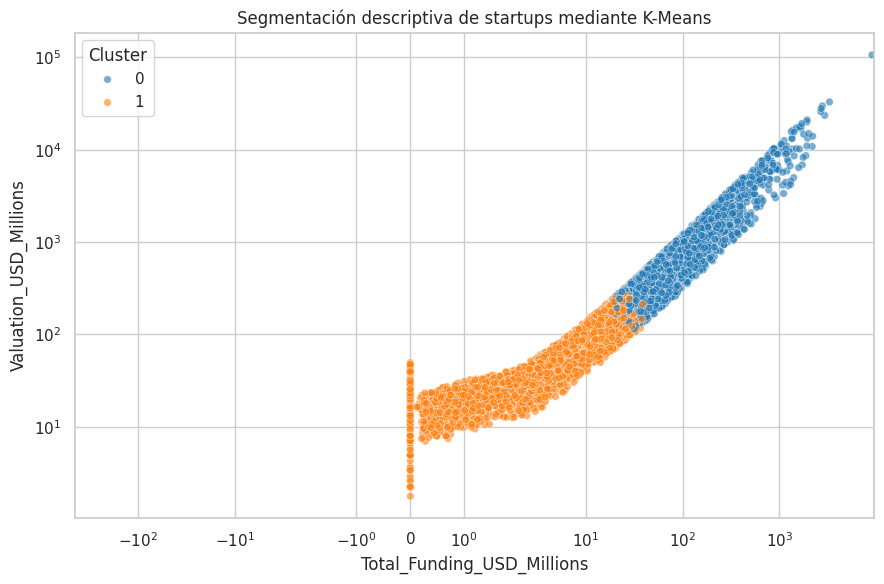

In [ ]:
best_k = int(silhouette_df.loc[silhouette_df["silhouette"].idxmax(), "k"])
print("Mejor k:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=random_state, n_init=10)
df_model["Cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_profile = (
    df_model.groupby("Cluster")
    .agg({
        "Company_ID": "count",
        "Total_Funding_USD_Millions": "median",
        "Valuation_USD_Millions": "median",
        "Revenue_ARR_Millions": "median",
        "Monthly_Burn_Rate_Millions": "median",
        "Startup_Age": "median"
    })
    .rename(columns={"Company_ID": "Cantidad"})
)
display(cluster_profile)

cluster_sample = df_model.sample(min(6000, len(df_model)), random_state=random_state)
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=cluster_sample,
    x="Total_Funding_USD_Millions",
    y="Valuation_USD_Millions",
    hue="Cluster", palette="tab10", alpha=0.6, s=30
)
plt.xscale("symlog")
plt.yscale("log")
plt.title("Segmentación descriptiva de startups mediante K-Means")
plt.tight_layout()
plt.show()

## 17. Resumen final

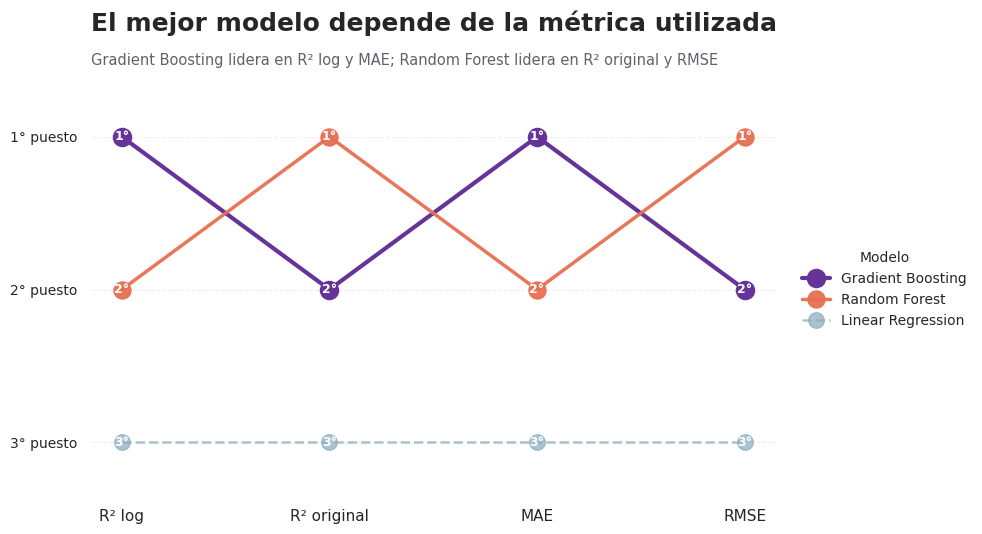


# Conclusión general

El análisis de **25,000 startups tecnológicas** muestra que la valuación está principalmente asociada con la escala financiera alcanzada por la empresa. El financiamiento total y los ingresos recurrentes anuales presentan relaciones monotónicas muy fuertes con la valuación, con coeficientes de Spearman de **0.960** y **0.943**, respectivamente.

## Factores asociados con la valuación

La etapa de financiamiento es uno de los elementos que mejor diferencia los niveles de valuación. La mediana aumenta de **USD 25.51 millones** en Seed a **USD 2,881.10 millones** en Post-IPO, lo que representa una diferencia aproximada de **112.9 veces**.

El dominio tecnológico también presenta diferencias estadísticamente significativas. **Generative AI** registra la mayor valuación mediana, con aproximadamente **USD 144.88 millones**. Sin embargo, la alta dispersión observada dentro de los sectores indica que pertenecer a un dominio determinado no garantiza por sí mismo una valuación elevada.

La ubicación geográfica muestra diferencias descriptivas, pero las distribuciones de los países se superponen considerablemente. Esto sugiere que el país aporta contexto, aunque parece tener menor capacidad explicativa que la etapa, el financiamiento o los ingresos.

## Capacidad predictiva

No existe un único modelo superior para todas las métricas:

- **Gradient Boosting** obtiene el mayor R² logarítmico, con **0.9730**, y también el menor MAE, de **USD 111.27 millones**.
- **Random Forest** obtiene el mejor R² en la escala monetaria original, con **0.8993**.
- **Random Forest** alcanza el menor RMSE, de **USD 687.12 millones**, por lo que controla mejor los errores monetarios de gran magnitud.

Para el objetivo principal se seleccionó **Gradient Boosting**, porque la transformación logarítmica reduce la influencia de las valuaciones extremas y permite modelar mejor las diferencias proporcionales entre startups.

La validación cruzada respalda la estabilidad del modelo: el R² logarítmico promedio fue **0.9735**, con un desvío de solamente **0.0005**. Por lo tanto, el desempeño no depende de una única división entre entrenamiento y prueba.

## Alcance de los errores

El error absoluto mediano fue de **USD 12.01 millones**, mientras que el 90% de las predicciones presentó un error inferior a aproximadamente **USD 197.43 millones**. El error porcentual mediano fue de **16.64%**.

Los errores aumentan considerablemente en startups valuadas por encima de USD 2.000 millones, donde el MAE alcanza **USD 1,234.97 millones**. Esto muestra que el modelo representa bien el comportamiento general, pero tiene más dificultad para estimar empresas extremadamente grandes o atípicas.

## Segmentación de las startups

El análisis de clustering seleccionó **2 grupos**, con un Silhouette Score de **0.483**. La segmentación diferencia principalmente:

- Un perfil de menor escala financiera, que representa aproximadamente **69.3%** de las startups y tiene una valuación mediana de **USD 39.53 millones**.
- Un perfil de mayor escala financiera, que representa aproximadamente **30.7%** y alcanza una valuación mediana de **USD 558.20 millones**.

Esto indica que la estructura general de los datos está determinada principalmente por diferencias de escala financiera, más que por la antigüedad de las compañías.

## Conclusión para inversionistas

Los resultados sugieren que las variables más útiles para evaluar una startup son su capacidad de generar ingresos, el financiamiento acumulado y la etapa de desarrollo alcanzada. El dominio tecnológico aporta información adicional, pero debe analizarse junto con los indicadores financieros.

El modelo puede utilizarse como una **herramienta inicial de comparación y apoyo**, especialmente para identificar rangos plausibles de valuación o casos que se alejan del comportamiento general. Sin embargo, no reemplaza una valuación financiera completa ni permite afirmar relaciones causales.

Finalmente, dado que el dataset es sintético, el proyecto demuestra la metodología analítica y predictiva, pero requeriría validación con información real y externa antes de utilizarse en decisiones de inversión.


In [ ]:
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --------------------------------------------------------------
# 1. EXTRAER LOS PRINCIPALES RESULTADOS
# --------------------------------------------------------------

# Valuación mediana por dominio
valuacion_dominio = (
    df.groupby("Domain")["Valuation_USD_Millions"]
    .median()
    .sort_values(ascending=False)
)

top_domain = valuacion_dominio.index[0]
top_domain_median = valuacion_dominio.iloc[0]


# Valuación mediana por etapa
stage_order = [
    "Seed",
    "Series A",
    "Series B",
    "Series C+",
    "Pre-IPO",
    "Post-IPO"
]

valuacion_etapa = (
    df.groupby("Funding_Stage")["Valuation_USD_Millions"]
    .median()
    .reindex(stage_order)
)

seed_median = valuacion_etapa.loc["Seed"]
post_ipo_median = valuacion_etapa.loc["Post-IPO"]

stage_multiple = (
    post_ipo_median / seed_median
)


# --------------------------------------------------------------
# 2. RESULTADOS DE LOS MODELOS
# --------------------------------------------------------------

model_results = (
    results_df
    .set_index("Modelo")
    .copy()
)

best_log = model_results["R2_log"].idxmax()
best_original = model_results["R2_original"].idxmax()
best_mae = model_results["MAE_USD_Millions"].idxmin()
best_rmse = model_results["RMSE_USD_Millions"].idxmin()

best_log_value = model_results.loc[
    best_log,
    "R2_log"
]

best_original_value = model_results.loc[
    best_original,
    "R2_original"
]

best_mae_value = model_results.loc[
    best_mae,
    "MAE_USD_Millions"
]

best_rmse_value = model_results.loc[
    best_rmse,
    "RMSE_USD_Millions"
]


# Validación cruzada
cv_mean = cv_df["R2_log"].mean()
cv_std = cv_df["R2_log"].std(ddof=0)


# --------------------------------------------------------------
# 3. RESULTADOS DEL ANÁLISIS DE ERRORES
# --------------------------------------------------------------

median_absolute_error = (
    error_df["Abs_Error"].median()
)

p90_absolute_error = (
    error_df["Abs_Error"].quantile(0.90)
)

median_percentage_error = (
    error_df["Error_Porcentual"].median()
)

large_startup_mae = errores_por_segmento.loc[
    "Más de USD 2.000 M",
    "MAE"
]


# --------------------------------------------------------------
# 4. RESULTADOS DEL CLUSTERING
# --------------------------------------------------------------

best_cluster_row = silhouette_df.loc[
    silhouette_df["silhouette"].idxmax()
]

best_k = int(best_cluster_row["k"])
best_silhouette = best_cluster_row["silhouette"]

cluster_summary = (
    cluster_profile
    .sort_values("Valuation_USD_Millions")
)

low_scale_cluster = cluster_summary.iloc[0]
high_scale_cluster = cluster_summary.iloc[-1]

low_scale_share = (
    low_scale_cluster["Cantidad"]
    / len(df_model)
    * 100
)

high_scale_share = (
    high_scale_cluster["Cantidad"]
    / len(df_model)
    * 100
)


# --------------------------------------------------------------
# 5. GRÁFICO NUEVO:
#    POSICIÓN DE LOS MODELOS SEGÚN CADA MÉTRICA
# --------------------------------------------------------------

model_ranks = pd.DataFrame(
    index=model_results.index
)

# En R², cuanto mayor, mejor
model_ranks["R² log"] = (
    model_results["R2_log"]
    .rank(ascending=False, method="min")
)

model_ranks["R² original"] = (
    model_results["R2_original"]
    .rank(ascending=False, method="min")
)

# En MAE y RMSE, cuanto menor, mejor
model_ranks["MAE"] = (
    model_results["MAE_USD_Millions"]
    .rank(ascending=True, method="min")
)

model_ranks["RMSE"] = (
    model_results["RMSE_USD_Millions"]
    .rank(ascending=True, method="min")
)


# Colores por modelo
model_colors = {
    "Gradient Boosting": "#663399",
    "Random Forest": "#E76F51",
    "Linear Regression": "#8FAFC1"
}

metricas = model_ranks.columns
posiciones_x = np.arange(len(metricas))

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10, 5.5))


# Dibujar una línea por modelo
for modelo in model_ranks.index:

    posiciones = model_ranks.loc[
        modelo
    ].values

    color = model_colors.get(
        modelo,
        "#777777"
    )

    # Modelo principal más destacado
    if modelo == "Gradient Boosting":
        grosor = 3
        tamaño = 170
        transparencia = 1
        estilo = "-"
    elif modelo == "Random Forest":
        grosor = 2.5
        tamaño = 150
        transparencia = 0.95
        estilo = "-"
    else:
        grosor = 1.8
        tamaño = 125
        transparencia = 0.75
        estilo = "--"

    ax.plot(
        posiciones_x,
        posiciones,
        color=color,
        linewidth=grosor,
        linestyle=estilo,
        alpha=transparencia,
        marker="o",
        markersize=np.sqrt(tamaño),
        label=modelo,
        zorder=3
    )

    # Número de posición dentro de cada punto
    for x, posicion in zip(
        posiciones_x,
        posiciones
    ):

        ax.text(
            x,
            posicion,
            f"{int(posicion)}°",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="white",
            zorder=4
        )


# El primer puesto aparece arriba
ax.invert_yaxis()

ax.set_yticks(
    [1, 2, 3]
)

ax.set_yticklabels(
    ["1° puesto", "2° puesto", "3° puesto"],
    fontsize=10
)

ax.set_xticks(posiciones_x)

ax.set_xticklabels(
    metricas,
    fontsize=11
)

ax.set_ylabel("")
ax.set_xlabel("")


# Título
ax.set_title(
    "El mejor modelo depende de la métrica utilizada",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=38
)

# Subtítulo
ax.text(
    0,
    1.045,
    "Gradient Boosting lidera en R² log y MAE; "
    "Random Forest lidera en R² original y RMSE",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#5F6368"
)


# Cuadrícula horizontal
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.30
)

ax.grid(
    axis="x",
    visible=False
)


# Espacio vertical
ax.set_ylim(
    3.35,
    0.65
)


# Leyenda
ax.legend(
    title="Modelo",
    frameon=False,
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    fontsize=10,
    title_fontsize=10
)


# Eliminar bordes
sns.despine(
    ax=ax,
    left=True,
    bottom=True
)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 6. RESUMEN TEXTUAL
# --------------------------------------------------------------

display(
    Markdown(
        f"""
# Conclusión general

El análisis de **{len(df):,} startups tecnológicas** muestra que la valuación está principalmente asociada con la escala financiera alcanzada por la empresa. El financiamiento total y los ingresos recurrentes anuales presentan relaciones monotónicas muy fuertes con la valuación, con coeficientes de Spearman de **{rho_funding:.3f}** y **{rho_arr:.3f}**, respectivamente.

## Factores asociados con la valuación

La etapa de financiamiento es uno de los elementos que mejor diferencia los niveles de valuación. La mediana aumenta de **USD {seed_median:,.2f} millones** en Seed a **USD {post_ipo_median:,.2f} millones** en Post-IPO, lo que representa una diferencia aproximada de **{stage_multiple:.1f} veces**.

El dominio tecnológico también presenta diferencias estadísticamente significativas. **{top_domain}** registra la mayor valuación mediana, con aproximadamente **USD {top_domain_median:,.2f} millones**. Sin embargo, la alta dispersión observada dentro de los sectores indica que pertenecer a un dominio determinado no garantiza por sí mismo una valuación elevada.

La ubicación geográfica muestra diferencias descriptivas, pero las distribuciones de los países se superponen considerablemente. Esto sugiere que el país aporta contexto, aunque parece tener menor capacidad explicativa que la etapa, el financiamiento o los ingresos.

## Capacidad predictiva

No existe un único modelo superior para todas las métricas:

- **{best_log}** obtiene el mayor R² logarítmico, con **{best_log_value:.4f}**, y también el menor MAE, de **USD {best_mae_value:,.2f} millones**.
- **{best_original}** obtiene el mejor R² en la escala monetaria original, con **{best_original_value:.4f}**.
- **{best_rmse}** alcanza el menor RMSE, de **USD {best_rmse_value:,.2f} millones**, por lo que controla mejor los errores monetarios de gran magnitud.

Para el objetivo principal se seleccionó **{best_log}**, porque la transformación logarítmica reduce la influencia de las valuaciones extremas y permite modelar mejor las diferencias proporcionales entre startups.

La validación cruzada respalda la estabilidad del modelo: el R² logarítmico promedio fue **{cv_mean:.4f}**, con un desvío de solamente **{cv_std:.4f}**. Por lo tanto, el desempeño no depende de una única división entre entrenamiento y prueba.

## Alcance de los errores

El error absoluto mediano fue de **USD {median_absolute_error:,.2f} millones**, mientras que el 90% de las predicciones presentó un error inferior a aproximadamente **USD {p90_absolute_error:,.2f} millones**. El error porcentual mediano fue de **{median_percentage_error:.2f}%**.

Los errores aumentan considerablemente en startups valuadas por encima de USD 2.000 millones, donde el MAE alcanza **USD {large_startup_mae:,.2f} millones**. Esto muestra que el modelo representa bien el comportamiento general, pero tiene más dificultad para estimar empresas extremadamente grandes o atípicas.

## Segmentación de las startups

El análisis de clustering seleccionó **{best_k} grupos**, con un Silhouette Score de **{best_silhouette:.3f}**. La segmentación diferencia principalmente:

- Un perfil de menor escala financiera, que representa aproximadamente **{low_scale_share:.1f}%** de las startups y tiene una valuación mediana de **USD {low_scale_cluster["Valuation_USD_Millions"]:,.2f} millones**.
- Un perfil de mayor escala financiera, que representa aproximadamente **{high_scale_share:.1f}%** y alcanza una valuación mediana de **USD {high_scale_cluster["Valuation_USD_Millions"]:,.2f} millones**.

Esto indica que la estructura general de los datos está determinada principalmente por diferencias de escala financiera, más que por la antigüedad de las compañías.

## Conclusión para inversionistas

Los resultados sugieren que las variables más útiles para evaluar una startup son su capacidad de generar ingresos, el financiamiento acumulado y la etapa de desarrollo alcanzada. El dominio tecnológico aporta información adicional, pero debe analizarse junto con los indicadores financieros.

El modelo puede utilizarse como una **herramienta inicial de comparación y apoyo**, especialmente para identificar rangos plausibles de valuación o casos que se alejan del comportamiento general. Sin embargo, no reemplaza una valuación financiera completa ni permite afirmar relaciones causales.

Finalmente, dado que el dataset es sintético, el proyecto demuestra la metodología analítica y predictiva, pero requeriría validación con información real y externa antes de utilizarse en decisiones de inversión.
"""
    )
)